In [1]:
# Colab setup: install packages not pre-installed on Colab.
# numpy/pandas/scipy/matplotlib already ship with Colab, so this is fast (~10-20s).
!pip install -q yfinance cvxpy tabulate


# Risk Parity vs Mean-Variance Optimization

**Universe:** 8 ETFs spanning US equity, international equity, investment-grade bonds, long
Treasuries, high yield, gold, broad commodities and REITs.
**Sample:** 2010–2024 daily. **Out-of-sample backtest:** 2015–2024, 252-day lookback, monthly rebalance.

**Pipeline:** EDA → Efficient Frontier → Risk Parity → Black-Litterman → Backtest → Sensitivity → Conclusion

---

### The question this notebook is actually asking

Markowitz gives the mathematically optimal portfolio *given* the inputs $\mu$ and $\Sigma$. The
problem is that $\mu$ is unknowable to the precision the optimizer assumes, and the optimizer
responds to that uncertainty in the worst possible way: it loads onto whichever asset has the
highest estimated return, which is disproportionately likely to be the one whose mean was *most
overestimated*. Michaud's term for this is the **error-maximizing** property.

Risk parity's response is not a better estimate of $\mu$. It is to drop $\mu$ from the problem
entirely and allocate on risk alone. Sections 6 and 7 quantify what that buys and what it costs.

### How to run

Prices are downloaded with `yfinance` and cached to CSV. If the download fails (no network, rate
limit, API change) the notebook falls back to a **synthetic multi-asset generator** built from a
four-factor model with realistic vols, correlations, fat tails and crisis regimes, so every cell
below still executes. All downstream code is identical on both paths.

```
pip install yfinance cvxpy
```

`cvxpy` is strongly recommended but optional — `scipy.optimize` fallbacks are provided for every
optimization.

## 0. Setup

In [2]:
# ============================================================================
# Imports and configuration
# ============================================================================
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from scipy.optimize import minimize

from IPython.display import Markdown, display

warnings.filterwarnings("ignore")
%matplotlib inline

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

RANDOM_SEED = 7
np.random.seed(RANDOM_SEED)

# ============================================================================
# CONFIG
# ============================================================================
TICKERS = ["SPY", "EFA", "AGG", "TLT", "HYG", "GLD", "DBC", "VNQ"]
ASSET_CLASS = {
    "SPY": "US equity",        "EFA": "Intl equity",   "AGG": "IG bonds",
    "TLT": "Long Treasuries",  "HYG": "High yield",    "GLD": "Gold",
    "DBC": "Commodities",      "VNQ": "REITs",
}

START_DATE = "2010-01-01"
END_DATE   = "2024-12-31"

BACKTEST_START = "2015-01-01"   # out-of-sample period
LOOKBACK_DAYS  = 252            # 1y rolling estimation window
REBALANCE      = "ME"           # month-end rebalancing
TC_BPS         = 10             # round-trip transaction cost, bps of turnover

RF_ANNUAL      = 0.02           # constant risk-free rate for Sharpe (see note below)
TRADING_DAYS   = 252

CACHE_PATH     = "prices_cache.csv"

# Optional dependency ---------------------------------------------------------
try:
    import cvxpy as cp
    HAS_CVXPY = True
except ImportError:
    HAS_CVXPY = False

print(f"numpy {np.__version__} | pandas {pd.__version__}")
import scipy; print(f"scipy {scipy.__version__}")
print(f"cvxpy {cp.__version__ if HAS_CVXPY else 'not installed (scipy fallback active)'}")
print(f"\nUniverse ({len(TICKERS)} assets):")
for t in TICKERS:
    print(f"  {t:5s} {ASSET_CLASS[t]}")

numpy 2.0.2 | pandas 2.2.2
scipy 1.16.3
cvxpy 1.6.7

Universe (8 assets):
  SPY   US equity
  EFA   Intl equity
  AGG   IG bonds
  TLT   Long Treasuries
  HYG   High yield
  GLD   Gold
  DBC   Commodities
  VNQ   REITs


### A note on the risk-free rate

Sharpe ratios below use a **constant** 2% annual risk-free rate. This is a simplification worth
naming out loud: the actual 3-month T-bill went from ~0% (2010–2015) to ~5% (2023–2024). Using a
constant rate slightly flatters Sharpe in the ZIRP years and penalises it in 2023–24.

The reason it does not change the *comparison* is that all strategies are fully invested and
unlevered, so they are all penalised identically — the ranking is unaffected. It would matter if
any strategy used leverage, which is exactly the case for institutional risk parity (section 9).

## 1. Data

### 1.1 Why these assets

The universe is chosen so the covariance matrix has genuine structure to exploit. If you run this
comparison on eight large-cap US equity ETFs, everything correlates at 0.95, $\Sigma$ is nearly
rank-one, and both optimizers degenerate — risk parity collapses toward equal weight and
mean-variance produces unstable corner solutions because near-collinear assets are nearly
interchangeable from the optimizer's point of view.

Spanning asset classes gives blocks of low and negative correlation, which is the whole reason
diversification has anything to work with.

In [3]:
# ============================================================================
# Price download: cache -> retry with exponential backoff -> synthetic fallback
# ============================================================================
import time
import random

# --- download behaviour (edit these) ----------------------------------------
MAX_RETRIES   = 4       # attempts before giving up and falling back to synthetic
BACKOFF_BASE  = 2.0     # delay = BACKOFF_BASE ** attempt + jitter, in seconds
FORCE_REFRESH = False   # True = ignore the cache and re-download

MIN_ROWS      = 3_000   # ~12y of trading days; a shorter panel means a bad download
MIN_COVERAGE  = 0.95    # min fraction of non-NaN observations per ticker
MAX_START_LAG = 45      # days the first observation may lag the requested start


def _extract_close(raw, tickers):
    """Pull the Close panel out of whatever shape yfinance returned.

    yfinance has used several column layouts across versions: a flat frame for a
    single ticker, ('Close', ticker) with the default group_by='column', and
    (ticker, 'Close') with group_by='ticker'. Detect rather than assume.
    """
    if isinstance(raw.columns, pd.MultiIndex):
        if "Close" in set(raw.columns.get_level_values(0)):
            px = raw["Close"]
        elif "Close" in set(raw.columns.get_level_values(1)):
            px = raw.xs("Close", axis=1, level=1)
        else:
            raise RuntimeError(f"no Close level found in columns: {raw.columns[:4].tolist()}")
    else:
        if "Close" in raw.columns:
            px = raw[["Close"]]
            if len(tickers) == 1:
                px.columns = list(tickers)
        else:
            px = raw
    return px.reindex(columns=list(tickers))


def _validate_panel(px, tickers, start):
    """Return (ok, reason). Rejects silently-truncated or partial downloads.

    This matters more than it looks. A download that quietly returns 6 of 8
    tickers, or starts in 2013 because one ETF's history was unavailable, will
    run all the way through the notebook and produce plausible-looking numbers
    computed on the wrong sample.
    """
    if px is None or px.empty:
        return False, "empty frame"
    missing = [t for t in tickers if t not in px.columns]
    if missing:
        return False, f"tickers absent from response: {missing}"
    all_nan = [t for t in tickers if px[t].notna().sum() == 0]
    if all_nan:
        return False, f"tickers with no data at all: {all_nan}"
    if len(px) < MIN_ROWS:
        return False, f"only {len(px)} rows, expected >= {MIN_ROWS}"

    cov = px.notna().mean()
    worst = cov.idxmin()
    if cov.min() < MIN_COVERAGE:
        return False, f"{worst} only {cov.min():.1%} covered (need {MIN_COVERAGE:.0%})"

    # Every ticker must have data close to the requested start date, otherwise
    # one late-starting series silently shortens the whole study.
    want = pd.Timestamp(start)
    for t in tickers:
        first = px[t].first_valid_index()
        if first is not None and (first - want).days > MAX_START_LAG:
            return False, f"{t} starts {first:%Y-%m-%d}, {(first - want).days} days after {start}"
    return True, "ok"


def download_prices(tickers, start, end, cache=CACHE_PATH, max_retries=MAX_RETRIES,
                    backoff_base=BACKOFF_BASE, force_refresh=FORCE_REFRESH):
    """Adjusted close prices from Yahoo, with caching and retry/backoff.

    Order of operations:
      1. Serve from the local CSV cache if it exists and validates.
      2. Otherwise download, retrying transient failures (rate limits, timeouts)
         with exponential backoff plus jitter.
      3. Validate before caching, so a bad download is never persisted.
      4. Return (None, None) if everything fails, which signals the caller to
         fall back to the synthetic generator.

    Returns (DataFrame, source_label) or (None, None).
    """
    # ---- 1. cache ----------------------------------------------------------
    if cache and os.path.exists(cache) and not force_refresh:
        try:
            cached = pd.read_csv(cache, index_col=0, parse_dates=True)
            if set(tickers).issubset(cached.columns):
                px = cached[list(tickers)].loc[start:end]
                ok, reason = _validate_panel(px, tickers, start)
                if ok:
                    age = (time.time() - os.path.getmtime(cache)) / 86400
                    print(f"Loaded {len(px):,} rows from cache '{cache}' "
                          f"(written {age:.1f} days ago).")
                    print("   Set FORCE_REFRESH = True to re-download.")
                    return px, f"Yahoo Finance (cached: {cache})"
                print(f"Cache failed validation ({reason}); re-downloading.")
            else:
                print("Cache is missing some tickers; re-downloading.")
        except Exception as exc:
            print(f"Could not read cache ({type(exc).__name__}: {exc}); re-downloading.")

    # ---- 2. download with retries -----------------------------------------
    for attempt in range(1, max_retries + 1):
        try:
            import logging
            import yfinance as yf
            # yfinance logs a wall of per-ticker errors; we surface one clean
            # message per attempt instead.
            logging.getLogger("yfinance").setLevel(logging.CRITICAL)

            # auto_adjust=True is NOT optional here: AGG, TLT and HYG pay large
            # distributions, and unadjusted closes would understate their total
            # return by several percent a year and distort every covariance.
            raw = yf.download(tickers, start=start, end=end, auto_adjust=True,
                              progress=False, threads=True)
            px = _extract_close(raw, tickers).dropna(how="all")

            ok, reason = _validate_panel(px, tickers, start)
            if not ok:
                raise RuntimeError(reason)

            if cache:
                px.to_csv(cache)
                print(f"Downloaded {len(px):,} rows -> cached to '{cache}'.")
            return px, "Yahoo Finance (live download)"

        except Exception as exc:
            label = f"{type(exc).__name__}: {exc}"
            if attempt >= max_retries:
                print(f"Attempt {attempt}/{max_retries} failed ({label}).")
                print("All download attempts failed.")
                break
            # Exponential backoff with jitter. Jitter matters for Yahoo's rate
            # limiter: fixed delays from many clients re-collide on retry.
            delay = backoff_base ** attempt + random.uniform(0, 1)
            print(f"Attempt {attempt}/{max_retries} failed ({label}). "
                  f"Retrying in {delay:.1f}s...")
            time.sleep(delay)

    return None, None

### 1.2 Synthetic fallback

Used only when the download fails. Prices are generated from a **four-factor model** — equity,
duration, credit and commodity — because that is the structure that actually produces a realistic
correlation matrix. Drawing eight independent series and imposing a correlation target afterwards
gets the pairwise numbers right but the *eigenstructure* wrong, and eigenstructure is precisely
what an optimizer keys on.

Three features are deliberately built in:

- **Fat tails** — Student-$t$ factor innovations ($\nu = 5$), so tail correlation is not Gaussian.
- **Volatility regimes** — multipliers over 2011 (Euro crisis), 2018Q4, 2020 (COVID) and 2022.
- **A 2022 that hurts** — equities *and* duration both sold off. This matters enormously for the
  conclusions: 2022 is the year risk parity's structural long-duration tilt worked against it, and
  a synthetic sample without it would make risk parity look better than it deserves.

In [4]:
def make_synthetic_prices(tickers, start, end, seed=RANDOM_SEED):
    """Four-factor synthetic multi-asset price panel with regimes and fat tails."""
    r = np.random.default_rng(seed)
    dates = pd.bdate_range(start, end)
    n = len(dates)

    # ---- factor loadings: rows = assets, cols = [equity, duration, credit, commodity]
    B = pd.DataFrame(
        [[1.00,  0.00, 0.10, 0.05],   # SPY
         [0.95,  0.00, 0.10, 0.15],   # EFA
         [0.00,  0.35, 0.15, 0.00],   # AGG
         [-0.05, 1.00, 0.00, 0.00],   # TLT
         [0.35,  0.25, 0.60, 0.05],   # HYG
         [0.00,  0.25, 0.00, 0.35],   # GLD
         [0.25,  0.00, 0.00, 1.00],   # DBC
         [0.90,  0.35, 0.20, 0.00]],  # VNQ
        index=["SPY", "EFA", "AGG", "TLT", "HYG", "GLD", "DBC", "VNQ"],
        columns=["equity", "duration", "credit", "commodity"])

    # ---- volatility regimes: crisis windows scale ALL factor innovations -----
    vol_mult = pd.Series(1.0, index=dates)
    for lo, hi, m in [("2011-08-01", "2011-10-31", 1.9),
                      ("2015-08-01", "2015-09-30", 1.5),
                      ("2018-10-01", "2018-12-31", 1.6),
                      ("2020-02-20", "2020-04-30", 3.5),
                      ("2022-01-01", "2022-10-31", 1.6)]:
        vol_mult.loc[lo:hi] = m

    # ---- directional shocks: crises have a sign, not just a magnitude -------
    drift_shock = pd.DataFrame(0.0, index=dates, columns=B.columns)
    drift_shock.loc["2020-02-20":"2020-03-23", "equity"] = -0.030    # COVID crash
    drift_shock.loc["2020-02-20":"2020-03-23", "credit"] = -0.020
    drift_shock.loc["2020-04-01":"2020-08-31", "equity"] = +0.006    # V-shaped recovery
    # 2022: stocks AND bonds fall together -- the scenario that breaks the
    # standard 60/40 and hurts duration-tilted risk parity most.
    drift_shock.loc["2022-01-01":"2022-10-31", "equity"]   = -0.0016
    drift_shock.loc["2022-01-01":"2022-10-31", "duration"] = -0.0022
    drift_shock.loc["2011-08-01":"2011-09-30", "equity"]   = -0.004

    # ---- factor innovations: Student-t for fat tails ------------------------
    nu = 5
    F = r.standard_t(nu, size=(n, 4)) / np.sqrt(nu / (nu - 2))   # unit variance
    F = F * 0.01 * vol_mult.to_numpy()[:, None] + drift_shock.to_numpy()

    # ---- idiosyncratic noise ------------------------------------------------
    idio = r.standard_t(nu, size=(n, len(B))) / np.sqrt(nu / (nu - 2)) * 0.004
    log_ret = pd.DataFrame(F @ B.T.to_numpy() + idio, index=dates, columns=B.index)

    # ---- rescale to realistic annualised vol / drift -----------------------
    # Linear rescaling preserves the correlation structure exactly while hitting
    # the target moments. Regime heteroskedasticity survives the rescale.
    target_vol  = {"SPY": .160, "EFA": .180, "AGG": .045, "TLT": .135,
                   "HYG": .085, "GLD": .150, "DBC": .170, "VNQ": .200}
    target_mean = {"SPY": .125, "EFA": .055, "AGG": .020, "TLT": .015,
                   "HYG": .050, "GLD": .060, "DBC": .005, "VNQ": .075}
    for t in log_ret.columns:
        z = (log_ret[t] - log_ret[t].mean()) / log_ret[t].std()
        log_ret[t] = z * (target_vol[t] / np.sqrt(TRADING_DAYS)) \
                     + target_mean[t] / TRADING_DAYS

    prices = 100 * np.exp(log_ret.cumsum())
    return prices.reindex(columns=tickers)


prices, DATA_SOURCE = download_prices(TICKERS, START_DATE, END_DATE)

if prices is None:
    print("\nFalling back to the synthetic generator.")
    prices = make_synthetic_prices(TICKERS, START_DATE, END_DATE)
    DATA_SOURCE = "SYNTHETIC (four-factor generator)"

IS_SYNTHETIC = DATA_SOURCE.startswith("SYNTHETIC")

prices_unfilled = prices.copy()            # kept for the integrity audit below
# Forward-fill isolated gaps (differing exchange holidays), then drop leading NaN.
prices = prices.ffill().dropna()

# ---- unmissable provenance banner -----------------------------------------
bar = "=" * 78
if IS_SYNTHETIC:
    print(f"\n{bar}\n  DATA SOURCE: *** SYNTHETIC ***  —  illustrative only, do not quote "
          f"these numbers\n{bar}")
else:
    print(f"\n{bar}\n  DATA SOURCE: REAL MARKET DATA  —  {DATA_SOURCE}\n{bar}")
print(f"Period : {prices.index[0]:%Y-%m-%d} to {prices.index[-1]:%Y-%m-%d} "
      f"({len(prices):,} trading days)")
prices.tail(3).round(2)

Downloaded 3,773 rows -> cached to 'prices_cache.csv'.

  DATA SOURCE: REAL MARKET DATA  —  Yahoo Finance (live download)
Period : 2010-01-04 to 2024-12-30 (3,773 trading days)


Ticker,SPY,EFA,AGG,TLT,HYG,GLD,DBC,VNQ
Date,,,,,,,,
2024-12-26,591.22,72.44,90.98,81.88,71.89,243.07,20.30,84.60
2024-12-27,584.99,72.34,90.79,81.21,71.64,241.40,20.39,83.75
2024-12-30,578.32,71.86,91.15,81.87,71.74,240.63,20.58,83.33


### 1.2b Data integrity audit

Run this before trusting anything downstream. It answers the questions that silently ruin a
multi-asset study: did every ticker actually return its full history, are there gaps long enough
to distort a 252-day window, and are there single-day moves large enough to suggest an
unadjusted split or a bad print rather than a real market event.

On synthetic data everything passes trivially. On real data this is the cell that earns its keep.

In [5]:
# ============================================================================
# Per-ticker data integrity checks
# ============================================================================
audit_rows = []
for t in TICKERS:
    s_raw = prices_unfilled[t]
    obs = s_raw.dropna()
    # longest run of consecutive business days with no observation
    if len(obs) > 1:
        gaps = obs.index.to_series().diff().dt.days.fillna(0)
        max_gap = int(gaps.max())
    else:
        max_gap = np.nan
    r = prices[t].pct_change().dropna()
    # exactly repeated consecutive prices = stale/carried-forward quotes
    stale = int((prices[t].diff() == 0).sum())
    audit_rows.append({
        "ticker": t,
        "first": obs.index[0].date() if len(obs) else None,
        "last": obs.index[-1].date() if len(obs) else None,
        "obs": len(obs),
        "missing": int(s_raw.isna().sum()),
        "max gap (cal. days)": max_gap,
        "stale days": stale,
        "max 1d move": r.abs().max(),
        "days |move|>10%": int((r.abs() > 0.10).sum()),
    })
audit = pd.DataFrame(audit_rows).set_index("ticker")
display(audit.style.format({"max 1d move": "{:.1%}"}))

flags = []
if audit["obs"].std() > 30:
    flags.append(f"Ticker histories differ in length by up to "
                 f"{audit['obs'].max() - audit['obs'].min()} observations — check the short one.")
if audit["max gap (cal. days)"].max() > 10:
    worst = audit["max gap (cal. days)"].idxmax()
    flags.append(f"{worst} has a {audit.loc[worst, 'max gap (cal. days)']}-day gap; "
                 f"a gap inside a 252-day window biases that window's covariance.")
if audit["max 1d move"].max() > 0.25:
    worst = audit["max 1d move"].idxmax()
    flags.append(f"{worst} moved {audit.loc[worst, 'max 1d move']:.0%} in one day — verify this "
                 f"is a real event (Mar 2020) and not an unadjusted split or bad print.")
if audit["stale days"].max() > len(prices) * 0.02:
    worst = audit["stale days"].idxmax()
    flags.append(f"{worst} has {audit.loc[worst, 'stale days']} unchanged-price days, which "
                 f"understates its volatility and distorts every risk-based weight.")

if flags:
    print("FLAGS:")
    for f in flags:
        print(f"  ! {f}")
else:
    print("No integrity flags raised: full overlapping histories, no material gaps, "
          "no suspicious single-day moves.")

print(f"\nCommon sample: {prices.index[0]:%Y-%m-%d} to {prices.index[-1]:%Y-%m-%d}, "
      f"{len(prices):,} days x {len(TICKERS)} assets, zero missing after alignment.")

,first,last,obs,missing,max gap (cal. days),stale days,max 1d move,days |move|>10%
ticker,,,,,,,,
SPY,2010-01-04,2024-12-30,3773,0,5,12,10.9%,1
EFA,2010-01-04,2024-12-30,3773,0,5,28,11.0%,2
AGG,2010-01-04,2024-12-30,3773,0,5,53,4.0%,0
TLT,2010-01-04,2024-12-30,3773,0,5,14,7.5%,0
HYG,2010-01-04,2024-12-30,3773,0,5,55,6.5%,0
GLD,2010-01-04,2024-12-30,3773,0,5,13,8.8%,0
DBC,2010-01-04,2024-12-30,3773,0,5,75,7.9%,0
VNQ,2010-01-04,2024-12-30,3773,0,5,19,17.7%,2


No integrity flags raised: full overlapping histories, no material gaps, no suspicious single-day moves.

Common sample: 2010-01-04 to 2024-12-30, 3,773 days x 8 assets, zero missing after alignment.


### 1.3 Log returns vs simple returns — and why the notebook uses both

This trips people up in interviews, so it is worth being explicit.

**Log returns** $r_t = \ln(P_t / P_{t-1})$ aggregate cleanly *through time*:
$\sum_t r_t = \ln(P_T/P_0)$. They are closer to normally distributed and are the right input for
estimating volatility and covariance.

**Simple returns** $R_t = P_t/P_{t-1} - 1$ aggregate cleanly *across assets*: a portfolio's simple
return is $R_p = \sum_i w_i R_i$. **Log returns do not have this property** — $\ln$ of a weighted
sum is not the weighted sum of logs, so computing portfolio returns as $\sum_i w_i r_i$ is wrong.
It is a small error at daily frequency (second order in $r$) and a material one when returns are
large, which is exactly when it matters.

So: **estimate $\Sigma$ on log returns; compound the backtest on simple returns.** The covariance
difference between the two at daily frequency is negligible, and mixing them this way keeps both
the estimation and the accounting correct.

In [6]:
# ============================================================================
# Returns
# ============================================================================
log_ret    = np.log(prices / prices.shift(1)).dropna()       # for estimating Sigma
simple_ret = (prices / prices.shift(1) - 1).dropna()         # for compounding P&L
monthly_ret = (prices.resample("ME").last() / prices.resample("ME").last().shift(1) - 1).dropna()

print(f"Daily returns  : {log_ret.shape[0]:,} obs x {log_ret.shape[1]} assets")
print(f"Monthly returns: {monthly_ret.shape[0]:,} obs")

# Verify the aggregation claim above on real numbers rather than asserting it.
w_demo = np.repeat(1 / len(TICKERS), len(TICKERS))
port_simple = (simple_ret @ w_demo)
port_log_wrong = (log_ret @ w_demo)
correct_total = (1 + port_simple).prod() - 1
wrong_total = np.exp(port_log_wrong.sum()) - 1
print(f"\nEqual-weight total return, compounded correctly from simple returns: {correct_total:.2%}")
print(f"Same thing computed (incorrectly) as a weighted sum of log returns   : {wrong_total:.2%}")
print(f"Gap from the aggregation error over {len(simple_ret):,} days: "
      f"{(correct_total - wrong_total) * 100:.2f} pp")

Daily returns  : 3,772 obs x 8 assets
Monthly returns: 179 obs

Equal-weight total return, compounded correctly from simple returns: 143.29%
Same thing computed (incorrectly) as a weighted sum of log returns   : 115.81%
Gap from the aggregation error over 3,772 days: 27.48 pp


In [7]:
# ============================================================================
# Descriptive statistics -- the raw material both optimizers consume
# ============================================================================
ann_ret = (1 + simple_ret).prod() ** (TRADING_DAYS / len(simple_ret)) - 1
ann_vol = log_ret.std() * np.sqrt(TRADING_DAYS)


def max_drawdown(returns):
    """Worst peak-to-trough decline of the cumulative wealth curve."""
    wealth = (1 + returns).cumprod()
    return (wealth / wealth.cummax() - 1).min()


stats_tbl = pd.DataFrame({
    "asset class": [ASSET_CLASS[t] for t in simple_ret.columns],
    "ann. return": ann_ret,
    "ann. vol": ann_vol,
    "Sharpe": (ann_ret - RF_ANNUAL) / ann_vol,
    "skew": log_ret.skew(),
    "excess kurtosis": log_ret.kurtosis(),
    "max drawdown": simple_ret.apply(max_drawdown),
})
display(stats_tbl.style.format({
    "ann. return": "{:.2%}", "ann. vol": "{:.2%}", "Sharpe": "{:.2f}",
    "skew": "{:.2f}", "excess kurtosis": "{:.1f}", "max drawdown": "{:.1%}"}))

print("Excess kurtosis far above 0 means daily returns are not Gaussian. Mean-variance "
      "optimization does not strictly require normality — it requires that investors care only "
      "about the first two moments — but fat tails mean the variance number understates how bad "
      "the bad days get, for every method here.")

,asset class,ann. return,ann. vol,Sharpe,skew,excess kurtosis,max drawdown
Ticker,,,,,,,
SPY,US equity,13.70%,17.10%,0.68,-0.72,11.5,-33.7%
EFA,Intl equity,5.01%,18.57%,0.16,-0.82,10.0,-34.2%
AGG,IG bonds,2.31%,4.75%,0.07,-1.18,22.5,-18.4%
TLT,Long Treasuries,2.66%,15.28%,0.04,-0.02,3.5,-48.4%
HYG,High yield,5.10%,8.49%,0.37,-0.27,18.8,-22.0%
GLD,Gold,5.38%,15.53%,0.22,-0.51,4.8,-45.6%
DBC,Commodities,-0.24%,17.28%,-0.13,-0.65,4.1,-66.1%
VNQ,REITs,8.87%,20.84%,0.33,-1.14,19.7,-42.4%


Excess kurtosis far above 0 means daily returns are not Gaussian. Mean-variance optimization does not strictly require normality — it requires that investors care only about the first two moments — but fat tails mean the variance number understates how bad the bad days get, for every method here.


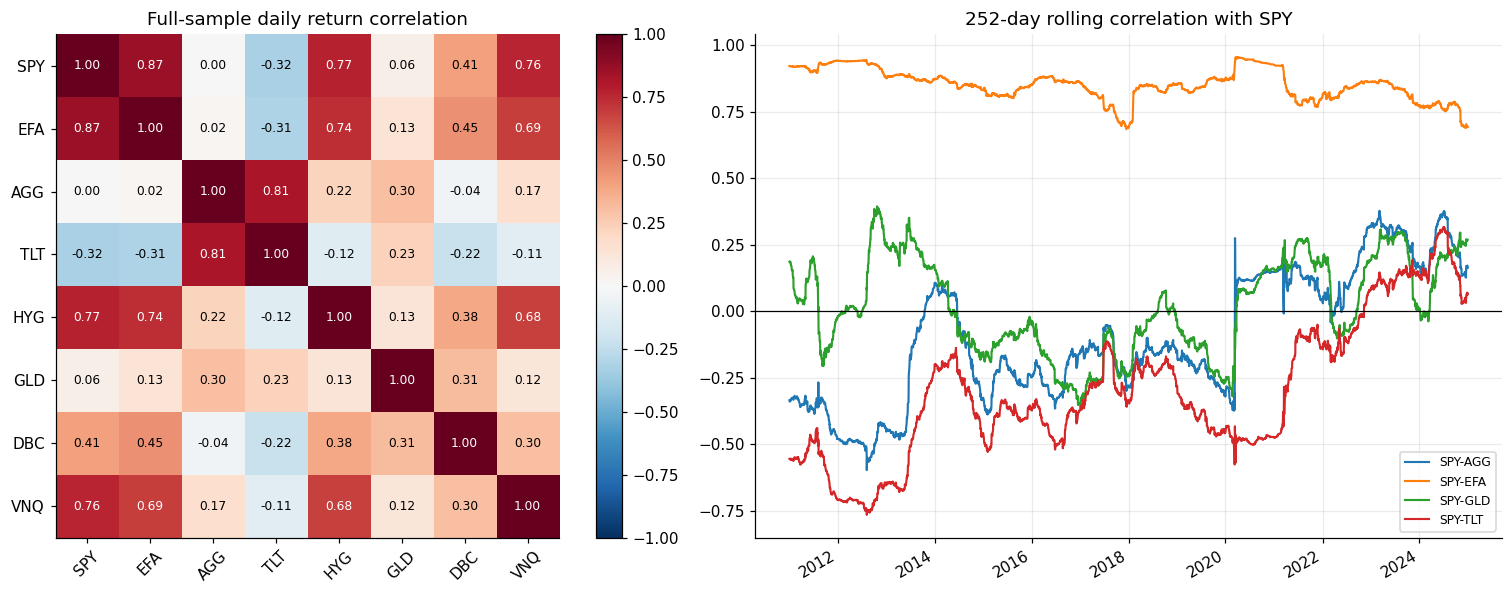

The stock-bond correlation is the single most important number in multi-asset allocation, and the rolling plot shows it is not a constant. It flipped from reliably negative (bonds hedge equity drawdowns) to positive in 2022 (both fall together). Risk parity's structural bond overweight is a bet on that correlation staying negative.


In [8]:
# ============================================================================
# Correlation structure -- the reason there is anything to optimize
# ============================================================================
corr = log_ret.corr()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

im = axes[0].imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
axes[0].set_xticks(range(len(corr)), corr.columns, rotation=45)
axes[0].set_yticks(range(len(corr)), corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        axes[0].text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8,
                     color="white" if abs(corr.iloc[i, j]) > 0.6 else "black")
axes[0].set_title("Full-sample daily return correlation")
axes[0].grid(False)
plt.colorbar(im, ax=axes[0], fraction=0.046)

# Rolling correlation: the assumption that Sigma is stable is the weak point of
# EVERY method here, not just mean-variance.
roll_corr = pd.DataFrame({
    f"{a}-{b}": log_ret[a].rolling(252).corr(log_ret[b])
    for a, b in [("SPY", "AGG"), ("SPY", "EFA"), ("SPY", "GLD"), ("SPY", "TLT")]
}).dropna()
roll_corr.plot(ax=axes[1], lw=1.4)
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_title("252-day rolling correlation with SPY")
axes[1].legend(fontsize=8); axes[1].set_xlabel("")

plt.tight_layout(); plt.show()

print("The stock-bond correlation is the single most important number in multi-asset allocation, "
      "and the rolling plot shows it is not a constant. It flipped from reliably negative "
      "(bonds hedge equity drawdowns) to positive in 2022 (both fall together). Risk parity's "
      "structural bond overweight is a bet on that correlation staying negative.")

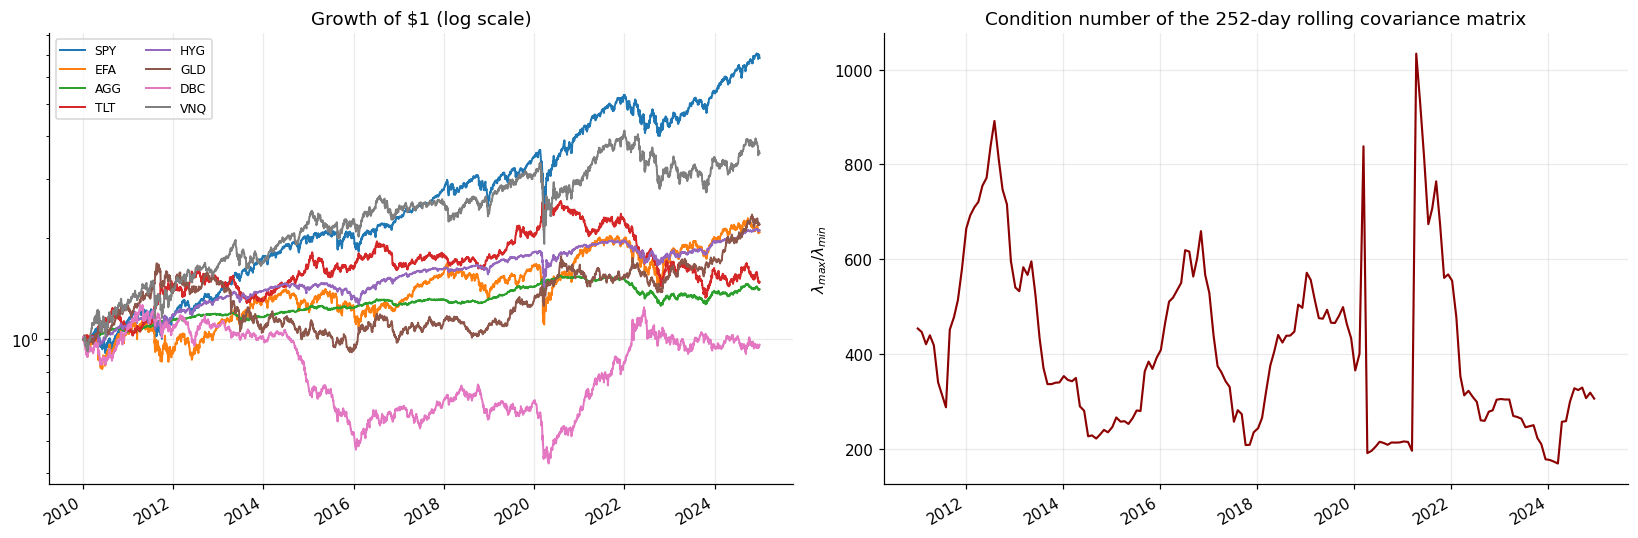

Condition number: median 357, max 1,034
Mean-variance weights are proportional to Sigma^-1 mu, so estimation error is amplified by roughly the condition number in the worst direction. Spikes correspond to crises, when correlations converge toward 1 and Sigma loses effective rank -- i.e. the optimizer is at its least reliable exactly when the allocation decision matters most.


In [9]:
# ============================================================================
# Cumulative performance and the conditioning of Sigma
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

(prices / prices.iloc[0]).plot(ax=axes[0], lw=1.3)
axes[0].set_yscale("log")
axes[0].set_title("Growth of $1 (log scale)")
axes[0].legend(fontsize=8, ncol=2); axes[0].set_xlabel("")

# Condition number of the rolling covariance matrix. A high condition number
# means Sigma is near-singular: the optimizer inverts it, so small estimation
# errors in the near-zero eigen-directions get amplified into huge weight swings.
cond = pd.Series(
    {log_ret.index[i]: np.linalg.cond(log_ret.iloc[i - 252:i].cov().to_numpy())
     for i in range(252, len(log_ret), 21)})
cond.plot(ax=axes[1], color="darkred", lw=1.4)
axes[1].set_title("Condition number of the 252-day rolling covariance matrix")
axes[1].set_ylabel(r"$\lambda_{max} / \lambda_{min}$")
axes[1].set_xlabel("")

plt.tight_layout(); plt.show()

print(f"Condition number: median {cond.median():,.0f}, max {cond.max():,.0f}")
print("Mean-variance weights are proportional to Sigma^-1 mu, so estimation error is amplified "
      "by roughly the condition number in the worst direction. Spikes correspond to crises, when "
      "correlations converge toward 1 and Sigma loses effective rank -- i.e. the optimizer is at "
      "its least reliable exactly when the allocation decision matters most.")

## 2. Estimating the inputs

### 2.1 Why $\mu$ is the problem and $\Sigma$ is not

The standard error of a sample mean return is

$$\text{SE}(\hat\mu) = \frac{\sigma}{\sqrt{T}}$$

where $T$ is the number of observations. Sample **more frequently** and $T$ rises — but $\sigma$
per observation falls by exactly the same factor, since variance scales linearly with the sampling
interval. Annualising, the two effects cancel:

$$\text{SE}(\hat\mu_{\text{annual}}) = \frac{\sigma_{\text{annual}}}{\sqrt{\text{years}}}$$

**The standard error of an expected return depends only on the calendar length of the sample, not
on how finely you sample it** (Merton, 1980). Fifteen years of tick data is worth no more than
fifteen years of annual data for estimating $\mu$.

Volatility is different. $\text{SE}(\hat\sigma) \approx \sigma/\sqrt{2T}$ *does* fall with sampling
frequency, so daily data genuinely improves a covariance estimate.

This asymmetry is the entire argument for risk parity. The cell below puts numbers on it.

In [10]:
# ============================================================================
# How precisely do we actually know these expected returns?
# ============================================================================
years = len(log_ret) / TRADING_DAYS
mu_hat = log_ret.mean() * TRADING_DAYS                 # annualised sample mean
sigma_hat = log_ret.std() * np.sqrt(TRADING_DAYS)      # annualised sample vol

se_mu = sigma_hat / np.sqrt(years)                     # SE of the mean estimate
se_sigma = sigma_hat / np.sqrt(2 * len(log_ret))       # SE of the vol estimate

precision = pd.DataFrame({
    "est. ann. return": mu_hat,
    "SE of return est.": se_mu,
    "t-stat": mu_hat / se_mu,
    "95% CI low": mu_hat - 1.96 * se_mu,
    "95% CI high": mu_hat + 1.96 * se_mu,
    "est. ann. vol": sigma_hat,
    "SE of vol est.": se_sigma,
})
display(precision.style.format({
    "est. ann. return": "{:.2%}", "SE of return est.": "{:.2%}", "t-stat": "{:.2f}",
    "95% CI low": "{:.2%}", "95% CI high": "{:.2%}",
    "est. ann. vol": "{:.2%}", "SE of vol est.": "{:.3%}"}))

n_sig = int((np.abs(mu_hat / se_mu) > 1.96).sum())
print(f"Sample length: {years:.1f} years")
print(f"{n_sig} of {len(TICKERS)} assets have a mean return statistically distinguishable "
      f"from zero at 95%.")
print(f"\nIn absolute annualised units, the SE of a mean estimate is "
      f"~{(se_mu / se_sigma).mean():.0f}x the SE of the corresponding volatility estimate.")
print("The confidence intervals on expected return are wider than the differences between assets "
      "that mean-variance optimization is being asked to act on. That is the whole problem: MVO "
      "treats these point estimates as if they were known constants.")

,est. ann. return,SE of return est.,t-stat,95% CI low,95% CI high,est. ann. vol,SE of vol est.
Ticker,,,,,,,
SPY,12.84%,4.42%,2.91,4.18%,21.51%,17.10%,0.197%
EFA,4.89%,4.80%,1.02,-4.52%,14.29%,18.57%,0.214%
AGG,2.28%,1.23%,1.86,-0.12%,4.69%,4.75%,0.055%
TLT,2.62%,3.95%,0.66,-5.12%,10.37%,15.28%,0.176%
HYG,4.97%,2.19%,2.27,0.68%,9.27%,8.49%,0.098%
GLD,5.24%,4.01%,1.31,-2.63%,13.11%,15.53%,0.179%
DBC,-0.24%,4.47%,-0.05,-9.00%,8.51%,17.28%,0.199%
VNQ,8.50%,5.39%,1.58,-2.06%,19.06%,20.84%,0.240%


Sample length: 15.0 years
2 of 8 assets have a mean return statistically distinguishable from zero at 95%.

In absolute annualised units, the SE of a mean estimate is ~22x the SE of the corresponding volatility estimate.
The confidence intervals on expected return are wider than the differences between assets that mean-variance optimization is being asked to act on. That is the whole problem: MVO treats these point estimates as if they were known constants.


### 2.2 Estimators used

Full-sample annualised moments are used for the in-sample frontier (sections 3–5); the backtest in
section 6 re-estimates both on a rolling 252-day window.

One numerical detail: sample covariance matrices can have tiny negative eigenvalues from
floating-point error, which breaks convex solvers that require positive semi-definiteness. Every
$\Sigma$ is passed through an eigenvalue-clipping projection first. This is a numerical guard, not
a shrinkage estimator — Ledoit-Wolf shrinkage is noted in the conclusion as the natural extension.

In [11]:
# ============================================================================
# Estimation helpers
# ============================================================================

def nearest_psd(S, eps=1e-10):
    """Project a symmetric matrix onto the PSD cone by clipping eigenvalues.

    Guards against tiny negative eigenvalues from floating-point error, which
    would otherwise make cvxpy reject the quadratic form as non-convex.
    """
    S = np.asarray(S, dtype=float)
    S = (S + S.T) / 2                              # enforce exact symmetry
    vals, vecs = np.linalg.eigh(S)
    vals = np.clip(vals, eps, None)
    return vecs @ np.diag(vals) @ vecs.T


def annualised_moments(daily_log_returns, periods=TRADING_DAYS):
    """(mu, Sigma) annualised, as numpy arrays in the column order given."""
    mu = daily_log_returns.mean().to_numpy() * periods
    Sigma = nearest_psd(daily_log_returns.cov().to_numpy() * periods)
    return mu, Sigma


MU, SIGMA = annualised_moments(log_ret)
N = len(TICKERS)

print("Annualised expected returns (historical sample means):")
print(pd.Series(MU, index=TICKERS).map("{:.2%}".format).to_string())
print(f"\nSigma: {SIGMA.shape}, condition number {np.linalg.cond(SIGMA):,.0f}, "
      f"min eigenvalue {np.linalg.eigvalsh(SIGMA).min():.2e}")

Annualised expected returns (historical sample means):
SPY    12.84%
EFA     4.89%
AGG     2.28%
TLT     2.62%
HYG     4.97%
GLD     5.24%
DBC    -0.24%
VNQ     8.50%

Sigma: (8, 8), condition number 226, min eigenvalue 4.63e-04


## 3. Mean-Variance Optimization

### 3.1 The problem

Minimum-variance portfolio:

$$\min_w \; w^\top \Sigma w \quad \text{s.t.} \quad \mathbf{1}^\top w = 1, \; w \geq 0$$

Efficient frontier — the same problem with a return floor, swept across target levels:

$$\min_w \; w^\top \Sigma w \quad \text{s.t.} \quad \mu^\top w \geq \mu_{\text{target}}, \; \mathbf{1}^\top w = 1, \; w \geq 0$$

Maximum-Sharpe (tangency) portfolio:

$$\max_w \; \frac{\mu^\top w - r_f}{\sqrt{w^\top \Sigma w}} \quad \text{s.t.} \quad \mathbf{1}^\top w = 1, \; w \geq 0$$

### 3.2 Making max-Sharpe convex

That last objective is a ratio and is **not concave**, so it cannot be handed to a convex solver
directly. Throwing it at `scipy.optimize.minimize` works but only finds a local optimum, and on a
near-singular $\Sigma$ the local optima can be far apart.

The standard fix is a change of variables. Substitute $y = w / (\mu - r_f\mathbf{1})^\top w$, i.e.
rescale so the portfolio's excess return is exactly 1. Then

$$\min_y \; y^\top \Sigma y \quad \text{s.t.} \quad (\mu - r_f\mathbf{1})^\top y = 1, \; y \geq 0$$

is a plain QP, and $w = y / \mathbf{1}^\top y$ recovers the tangency portfolio. This works because
the Sharpe ratio is scale-invariant in $w$, so we are free to fix the numerator and minimise the
denominator. It requires at least one asset with positive excess return, otherwise the constraint
set is empty — worth handling explicitly rather than letting the solver return garbage.

**The long-only constraint $w \geq 0$ is doing real work here.** Without it, mean-variance
solutions on this universe take enormous offsetting long/short positions in the near-collinear
assets (SPY vs EFA, AGG vs TLT), because the optimizer sees a tiny estimated return difference
between two 0.9-correlated assets as a nearly risk-free arbitrage. Section 7 shows this directly.
> **The tangency portfolio does not always exist.** If *no* asset has a positive estimated excess
> return over the lookback window — which happens in real rolling windows more often than you would
> guess — the constraint set $(\mu - r_f)^\top y = 1,\, y \geq 0$ is empty and there is no solution.
>
> Nor can you rescue it by maximising the Sharpe ratio directly: with a negative numerator, the
> ratio $(\mu^\top w - r_f)/\sigma_p$ is maximised by taking on *more* volatility, since dividing a
> negative number by a larger denominator makes it less negative. A naive optimizer handed a
> negative-excess-return window will happily pile into the riskiest asset available. The Sharpe
> ratio is simply not a meaningful objective when excess returns are negative.
>
> The convention used here is to fall back to the **minimum-variance portfolio** in those windows,
> and to count how often that happens so the backtest can be read honestly — those months are not
> really "mean-variance" months at all.

In [12]:
# ============================================================================
# Mean-variance optimizers (cvxpy primary, scipy fallback)
# ============================================================================

# Counts how often the tangency portfolio was undefined (see note above), so the
# backtest can report what fraction of its "max Sharpe" months were really
# min-variance months.
TANGENCY_UNDEFINED = {"count": 0, "total": 0}

def _simplex_x0(n):
    return np.repeat(1 / n, n)


def min_variance_weights(Sigma, long_only=True):
    """argmin w'Sigma w  s.t.  1'w = 1  (and w >= 0 if long_only)."""
    Sigma = nearest_psd(Sigma)
    n = len(Sigma)
    if HAS_CVXPY:
        w = cp.Variable(n)
        cons = [cp.sum(w) == 1] + ([w >= 0] if long_only else [])
        prob = cp.Problem(cp.Minimize(cp.quad_form(w, cp.psd_wrap(Sigma))), cons)
        prob.solve()
        if w.value is not None:
            return np.asarray(w.value).ravel()
    # scipy fallback
    cons = [{"type": "eq", "fun": lambda w: w.sum() - 1}]
    bounds = [(0, 1)] * n if long_only else [(-2, 2)] * n
    res = minimize(lambda w: w @ Sigma @ w, _simplex_x0(n),
                   method="SLSQP", bounds=bounds, constraints=cons)
    return res.x


def efficient_frontier_point(mu, Sigma, target_return, long_only=True):
    """Min variance subject to a return floor. Returns None if infeasible."""
    Sigma = nearest_psd(Sigma)
    n = len(Sigma)
    if HAS_CVXPY:
        w = cp.Variable(n)
        cons = [cp.sum(w) == 1, mu @ w >= target_return] + ([w >= 0] if long_only else [])
        prob = cp.Problem(cp.Minimize(cp.quad_form(w, cp.psd_wrap(Sigma))), cons)
        prob.solve()
        return None if w.value is None else np.asarray(w.value).ravel()
    cons = [{"type": "eq", "fun": lambda w: w.sum() - 1},
            {"type": "ineq", "fun": lambda w: mu @ w - target_return}]
    bounds = [(0, 1)] * n if long_only else [(-2, 2)] * n
    res = minimize(lambda w: w @ Sigma @ w, _simplex_x0(n),
                   method="SLSQP", bounds=bounds, constraints=cons)
    return res.x if res.success else None


def max_sharpe_weights(mu, Sigma, rf=RF_ANNUAL, long_only=True):
    """Tangency portfolio via the y = w / excess-return change of variables."""
    Sigma = nearest_psd(Sigma)
    n = len(Sigma)
    excess = mu - rf
    TANGENCY_UNDEFINED["total"] += 1

    # Guard: with no positive excess return the tangency portfolio is undefined
    # and maximising the Sharpe ratio is perverse (see the note above).
    if excess.max() <= 0:
        TANGENCY_UNDEFINED["count"] += 1
        return min_variance_weights(Sigma, long_only)

    if HAS_CVXPY:
        y = cp.Variable(n)
        cons = [excess @ y == 1] + ([y >= 0] if long_only else [cp.sum(y) >= 1e-6])
        prob = cp.Problem(cp.Minimize(cp.quad_form(y, cp.psd_wrap(Sigma))), cons)
        prob.solve()
        if y.value is not None and np.sum(y.value) > 1e-10:
            return np.asarray(y.value).ravel() / np.sum(y.value)

    # scipy fallback: maximise Sharpe directly (non-convex, local optimum only)
    def neg_sharpe(w):
        vol = np.sqrt(w @ Sigma @ w)
        return -(mu @ w - rf) / vol if vol > 1e-12 else 1e6
    cons = [{"type": "eq", "fun": lambda w: w.sum() - 1}]
    bounds = [(0, 1)] * n if long_only else [(-2, 2)] * n
    res = minimize(neg_sharpe, _simplex_x0(n), method="SLSQP",
                   bounds=bounds, constraints=cons)
    return res.x


def portfolio_stats(w, mu, Sigma, rf=RF_ANNUAL):
    """Annualised (return, vol, Sharpe) for a weight vector."""
    ret = float(mu @ w)
    vol = float(np.sqrt(w @ Sigma @ w))
    return ret, vol, (ret - rf) / vol if vol > 0 else np.nan


w_minvar = min_variance_weights(SIGMA)
w_maxsharpe = max_sharpe_weights(MU, SIGMA)

for name, w in [("Min variance", w_minvar), ("Max Sharpe", w_maxsharpe)]:
    r, v, s = portfolio_stats(w, MU, SIGMA)
    print(f"{name:14s} ret {r:6.2%} | vol {v:6.2%} | Sharpe {s:5.2f} | "
          f"assets held {np.sum(w > 0.01):d}/{N}")
    print("   " + "  ".join(f"{t}={x:5.1%}" for t, x in zip(TICKERS, w)))

Min variance   ret  2.51% | vol  4.42% | Sharpe  0.12 | assets held 3/8
   SPY= 0.0%  EFA= 0.0%  AGG=82.1%  TLT=-0.0%  HYG=13.0%  GLD=-0.0%  DBC= 4.9%  VNQ= 0.0%
Max Sharpe     ret  9.47% | vol 10.77% | Sharpe  0.69 | assets held 3/8
   SPY=64.1%  EFA= 0.0%  AGG=-0.0%  TLT=24.5%  HYG=-0.0%  GLD=11.4%  DBC= 0.0%  VNQ=-0.0%


In [13]:
# ============================================================================
# The efficient frontier, long-only and unconstrained
# ============================================================================
targets = np.linspace(MU.min(), MU.max(), 40)

frontier = []
for tgt in targets:
    w = efficient_frontier_point(MU, SIGMA, tgt, long_only=True)
    if w is not None:
        r, v, s = portfolio_stats(w, MU, SIGMA)
        frontier.append({"target": tgt, "ret": r, "vol": v, "sharpe": s, "w": w})
frontier = pd.DataFrame(frontier)

frontier_ls = []
for tgt in np.linspace(MU.min() - 0.05, MU.max() + 0.05, 40):
    w = efficient_frontier_point(MU, SIGMA, tgt, long_only=False)
    if w is not None:
        r, v, s = portfolio_stats(w, MU, SIGMA)
        frontier_ls.append({"ret": r, "vol": v, "gross": np.abs(w).sum()})
frontier_ls = pd.DataFrame(frontier_ls)

print(f"Long-only frontier: {len(frontier)} feasible points")
print(f"Unconstrained frontier max gross exposure: {frontier_ls['gross'].max():.2f}x "
      f"(1.00 = fully invested, no leverage)")

Long-only frontier: 40 feasible points
Unconstrained frontier max gross exposure: 3.96x (1.00 = fully invested, no leverage)


## 4. Risk Parity

### 4.1 The risk contribution decomposition

Portfolio volatility is $\sigma_p(w) = \sqrt{w^\top \Sigma w}$. It is **homogeneous of degree 1**
in $w$: double every weight and volatility doubles. Euler's theorem for homogeneous functions then
gives an exact additive decomposition:

$$\sigma_p(w) = \sum_{i=1}^{N} w_i \frac{\partial \sigma_p}{\partial w_i}$$

The partial derivative is the **marginal risk contribution**:

$$\text{MRC}_i = \frac{\partial \sigma_p}{\partial w_i} = \frac{(\Sigma w)_i}{\sqrt{w^\top \Sigma w}}$$

so the **total risk contribution** of asset $i$ is

$$\boxed{\;\text{RC}_i = w_i \cdot \frac{(\Sigma w)_i}{\sqrt{w^\top \Sigma w}}\;}
\qquad \sum_i \text{RC}_i = \sigma_p$$

This is the reason risk parity is well defined at all: total portfolio risk splits *exactly* into
per-asset pieces that sum to the whole. That is not true of most risk measures — it works here
because volatility is homogeneous of degree 1, and it extends to VaR and expected shortfall for
the same reason.

**Equal risk contribution (ERC)** requires $\text{RC}_i = \sigma_p / N$ for all $i$, i.e.

$$w_i (\Sigma w)_i = w_j (\Sigma w)_j \quad \forall i,j$$

Note what is *absent*: $\mu$ appears nowhere. Risk parity has no opinion on expected returns.

### 4.2 Why not just solve $\text{RC}_i = \text{RC}_j$ directly

The naive approach — minimise $\sum_{i,j}(\text{RC}_i - \text{RC}_j)^2$ — is non-convex and gets
stuck in local minima. Spinu (2013) showed the ERC portfolio is the unique solution to a **convex**
problem:

$$\min_{y > 0} \; \tfrac{1}{2} y^\top \Sigma y - \sum_i b_i \ln y_i, \qquad w = \frac{y}{\mathbf{1}^\top y}$$

with $b_i$ the target risk budgets ($b_i = 1/N$ for equal risk). The log barrier keeps weights
strictly positive and, at the optimum, the first-order condition is $(\Sigma y)_i = b_i / y_i$,
i.e. $y_i(\Sigma y)_i = b_i$ — exactly the ERC condition after normalisation.

The implementation below is **cyclical coordinate descent** on that objective. Fixing all but one
coordinate, the first-order condition becomes a scalar quadratic

$$\Sigma_{ii} y_i^2 + \Big(\sum_{j \neq i}\Sigma_{ij}y_j\Big) y_i - b_i = 0$$

with the positive root taken in closed form. It converges in milliseconds with no solver
dependency, which matters because the backtest calls it ~120 times. The convex solver is used
afterwards to **verify** the coordinate-descent answer rather than to produce it.

In [14]:
# ============================================================================
# Risk parity
# ============================================================================

def risk_contributions(w, Sigma):
    """RC_i = w_i (Sigma w)_i / sigma_p. Sums to sigma_p by Euler's theorem."""
    w = np.asarray(w, dtype=float)
    port_vol = np.sqrt(w @ Sigma @ w)
    mrc = (Sigma @ w) / port_vol           # marginal risk contribution
    return w * mrc                          # total risk contribution


def risk_parity_weights(Sigma, budgets=None, tol=1e-12, max_iter=5000):
    """ERC weights via cyclical coordinate descent on the Spinu objective.

    Solves  min_{y>0} 0.5 y'Sigma y - sum_i b_i log(y_i),  then normalises.
    Each coordinate update solves Sigma_ii y_i^2 + c_i y_i - b_i = 0 in closed form.
    """
    Sigma = nearest_psd(Sigma)
    n = len(Sigma)
    b = np.repeat(1 / n, n) if budgets is None else np.asarray(budgets, float)
    b = b / b.sum()

    # Inverse-volatility start: already the exact answer when all correlations
    # are equal, so it is a good warm start in general.
    y = 1 / np.sqrt(np.diag(Sigma))
    y = y / y.sum()

    for it in range(max_iter):
        y_prev = y.copy()
        for i in range(n):
            c = Sigma[i] @ y - Sigma[i, i] * y[i]      # cross term, excluding i
            # positive root of  Sigma_ii y^2 + c y - b_i = 0
            y[i] = (-c + np.sqrt(c ** 2 + 4 * Sigma[i, i] * b[i])) / (2 * Sigma[i, i])
        if np.max(np.abs(y - y_prev)) < tol:
            break
    return y / y.sum(), it + 1


def risk_parity_cvxpy(Sigma, budgets=None):
    """Same problem solved with a convex solver -- used to verify the CCD result."""
    if not HAS_CVXPY:
        return None
    Sigma = nearest_psd(Sigma)
    n = len(Sigma)
    b = np.repeat(1 / n, n) if budgets is None else np.asarray(budgets, float)
    y = cp.Variable(n, pos=True)
    obj = cp.Minimize(0.5 * cp.quad_form(y, cp.psd_wrap(Sigma)) - b @ cp.log(y))
    cp.Problem(obj).solve()
    return None if y.value is None else np.asarray(y.value).ravel() / np.sum(y.value)


w_rp, n_iter = risk_parity_weights(SIGMA)
print(f"Coordinate descent converged in {n_iter} sweeps")

# ---- verification 1: does the convex solver agree? -------------------------
w_rp_cvx = risk_parity_cvxpy(SIGMA)
if w_rp_cvx is not None:
    print(f"Max weight difference vs cvxpy solution: {np.abs(w_rp - w_rp_cvx).max():.2e}")

# ---- verification 2: are the risk contributions actually equal? ------------
rc = risk_contributions(w_rp, SIGMA)
port_vol = np.sqrt(w_rp @ SIGMA @ w_rp)

check = pd.DataFrame({
    "weight": w_rp,
    "ann. vol": np.sqrt(np.diag(SIGMA)),
    "marginal RC": (SIGMA @ w_rp) / port_vol,
    "risk contribution": rc,
    "% of total risk": rc / rc.sum(),
}, index=TICKERS)
display(check.style.format({
    "weight": "{:.2%}", "ann. vol": "{:.2%}", "marginal RC": "{:.4f}",
    "risk contribution": "{:.5f}", "% of total risk": "{:.4%}"}))

print(f"Sum of risk contributions : {rc.sum():.6f}")
print(f"Portfolio volatility      : {port_vol:.6f}   <- Euler decomposition is exact")
print(f"Target share per asset    : {1 / N:.4%}")
print(f"Max deviation from equal  : {np.abs(rc / rc.sum() - 1 / N).max():.2e}")
assert np.abs(rc / rc.sum() - 1 / N).max() < 1e-6, "risk contributions are not equal"
print("\nEqual risk contribution verified.")

Coordinate descent converged in 16 sweeps
Max weight difference vs cvxpy solution: 5.31e-06


,weight,ann. vol,marginal RC,risk contribution,% of total risk
SPY,7.92%,17.10%,0.1085,0.00859,12.5000%
EFA,7.09%,18.57%,0.1212,0.00859,12.5000%
AGG,28.92%,4.75%,0.0297,0.00859,12.5000%
TLT,15.93%,15.28%,0.0540,0.00859,12.5000%
HYG,14.09%,8.49%,0.0610,0.00859,12.5000%
GLD,10.38%,15.53%,0.0828,0.00859,12.5000%
DBC,9.60%,17.28%,0.0895,0.00859,12.5000%
VNQ,6.07%,20.84%,0.1415,0.00859,12.5000%


Sum of risk contributions : 0.068756
Portfolio volatility      : 0.068756   <- Euler decomposition is exact
Target share per asset    : 12.5000%
Max deviation from equal  : 8.05e-15

Equal risk contribution verified.


In [15]:
# ============================================================================
# Risk parity is NOT inverse-volatility weighting (a common conflation)
# ============================================================================
# Inverse-vol ignores correlation entirely. It coincides with ERC only when all
# pairwise correlations are identical. The gap below is the value of using the
# full covariance matrix instead of just the diagonal.
w_invvol = (1 / np.sqrt(np.diag(SIGMA))); w_invvol /= w_invvol.sum()
w_eq = np.repeat(1 / N, N)

cmp_tbl = pd.DataFrame({
    "equal weight": w_eq,
    "inverse vol": w_invvol,
    "risk parity (ERC)": w_rp,
    "min variance": w_minvar,
    "max Sharpe": w_maxsharpe,
}, index=TICKERS)
display(cmp_tbl.style.format("{:.2%}").background_gradient(cmap="Blues", axis=0))

rc_iv = risk_contributions(w_invvol, SIGMA)
print(f"Risk-contribution spread under inverse-vol weighting: "
      f"{(rc_iv / rc_iv.sum()).max() - (rc_iv / rc_iv.sum()).min():.2%} of total risk")
print(f"Risk-contribution spread under true ERC              : "
      f"{(rc / rc.sum()).max() - (rc / rc.sum()).min():.2e}")
print("\nInverse-vol over-allocates risk to assets that are highly correlated with the rest of "
      "the book, because it never looks at the off-diagonal terms.")

print("\nConcentration (Herfindahl index, 1/N = perfectly diversified weights):")
for name in cmp_tbl.columns:
    w = cmp_tbl[name].to_numpy()
    print(f"  {name:20s} HHI {np.sum(w ** 2):.3f}   effective N {1 / np.sum(w ** 2):.1f}")

,equal weight,inverse vol,risk parity (ERC),min variance,max Sharpe
SPY,12.50%,8.65%,7.92%,0.00%,64.06%
EFA,12.50%,7.97%,7.09%,0.00%,0.00%
AGG,12.50%,31.11%,28.92%,82.06%,-0.00%
TLT,12.50%,9.68%,15.93%,-0.00%,24.50%
HYG,12.50%,17.43%,14.09%,13.00%,-0.00%
GLD,12.50%,9.52%,10.38%,-0.00%,11.44%
DBC,12.50%,8.56%,9.60%,4.94%,0.00%
VNQ,12.50%,7.10%,6.07%,0.00%,-0.00%


Risk-contribution spread under inverse-vol weighting: 12.47% of total risk
Risk-contribution spread under true ERC              : 1.15e-14

Inverse-vol over-allocates risk to assets that are highly correlated with the rest of the book, because it never looks at the off-diagonal terms.

Concentration (Herfindahl index, 1/N = perfectly diversified weights):
  equal weight         HHI 0.125   effective N 8.0
  inverse vol          HHI 0.172   effective N 5.8
  risk parity (ERC)    HHI 0.164   effective N 6.1
  min variance         HHI 0.693   effective N 1.4
  max Sharpe           HHI 0.484   effective N 2.1


## 5. Black-Litterman (stretch)

### 5.1 The idea

Naive mean-variance takes historical sample means as $\mu$ and produces concentrated, unstable
portfolios. Black-Litterman changes the *starting point*: instead of asking "what returns does
history show?", it asks "what returns would make the market portfolio optimal?" and treats that as
the prior.

**Step 1 — reverse optimization.** If the market portfolio $w_{\text{mkt}}$ is the optimal holding
of a representative mean-variance investor, invert the first-order condition to recover the
implied equilibrium returns:

$$\pi = \delta \Sigma w_{\text{mkt}}, \qquad \delta = \frac{E[r_m] - r_f}{\sigma_m^2}$$

$\delta$ is the market's risk-aversion coefficient (typically 2–3).

**Step 2 — express views.** $P$ picks out the assets a view is about, $Q$ gives the expected
returns, $\Omega$ gives the uncertainty of each view. A relative view like "US equity beats
international equity by 2%" is the row $[1, -1, 0, \ldots]$ with $Q = 0.02$.

**Step 3 — blend.** The posterior is a precision-weighted average of prior and views:

$$\mu_{BL} = \left[(\tau\Sigma)^{-1} + P^\top\Omega^{-1}P\right]^{-1}
             \left[(\tau\Sigma)^{-1}\pi + P^\top\Omega^{-1}Q\right]$$

### 5.2 Why this stabilises weights

Two reasons, and the second is the one people miss.

1. The prior $\pi$ is *consistent with* $\Sigma$ by construction — it was generated by multiplying
   through by $\Sigma$. Feeding it back into $\Sigma^{-1}\mu$ recovers $w_{\text{mkt}}$ exactly, so
   with no views you get the market portfolio rather than a corner solution.
2. Views propagate through $\Sigma$. A view on SPY alone shifts the posterior for EFA too, because
   they are correlated. Naive MVO has no such mechanism: bumping one $\mu$ moves that asset's
   weight and leaves everything else to be sorted out by the optimizer, which is why small input
   changes cause large reshuffles.

**Caveat on $w_{\text{mkt}}$:** proper market weights need market caps and AUM. The proxy below is
a hand-set approximation of a global multi-asset market portfolio. On real data you would pull
actual fund AUM or index caps; the *mechanism* is unaffected, the specific numbers are not
defensible as-is.

In [16]:
# ============================================================================
# Black-Litterman
# ============================================================================

# Proxy for the global market portfolio (see caveat above).
W_MARKET = pd.Series({"SPY": 0.30, "EFA": 0.20, "AGG": 0.18, "TLT": 0.05,
                      "HYG": 0.05, "GLD": 0.05, "DBC": 0.05, "VNQ": 0.12})
W_MARKET = (W_MARKET / W_MARKET.sum()).reindex(TICKERS).to_numpy()


def black_litterman(Sigma, w_mkt, P, Q, tau=0.05, delta=None, rf=RF_ANNUAL,
                    mkt_excess=None, omega=None):
    """Posterior expected returns blending equilibrium prior with views.

    Returns (mu_bl, pi). Omega defaults to diag(P tau Sigma P'), the He-Litterman
    convention: each view's uncertainty is proportional to the prior variance of
    the portfolio the view is about, so no extra free parameter is introduced.
    """
    Sigma = nearest_psd(Sigma)
    if delta is None:
        # delta = market Sharpe / market vol = (E[r_m] - rf) / sigma_m^2
        sigma_m2 = float(w_mkt @ Sigma @ w_mkt)
        delta = (mkt_excess if mkt_excess is not None else 0.05) / sigma_m2

    pi = delta * Sigma @ w_mkt                       # implied equilibrium returns
    P = np.atleast_2d(P)
    Q = np.atleast_1d(Q).astype(float)
    if omega is None:
        omega = np.diag(np.diag(P @ (tau * Sigma) @ P.T))

    tau_sigma_inv = np.linalg.inv(tau * Sigma)
    omega_inv = np.linalg.inv(omega)
    cov_post = np.linalg.inv(tau_sigma_inv + P.T @ omega_inv @ P)
    mu_bl = cov_post @ (tau_sigma_inv @ pi + P.T @ omega_inv @ Q)
    return mu_bl, pi, delta


# ---- market-implied equilibrium returns ------------------------------------
mkt_excess_ret = float(MU @ W_MARKET) - RF_ANNUAL
mu_bl_noview, PI, DELTA = black_litterman(
    SIGMA, W_MARKET, P=np.zeros((1, N)), Q=[0.0],
    mkt_excess=mkt_excess_ret, omega=np.array([[1e6]]))   # 1e6 = "no information"

print(f"Implied risk-aversion delta: {DELTA:.2f}")

# ---- one relative view: US equity beats international equity by 2% ---------
P = np.zeros((1, N))
P[0, TICKERS.index("SPY")] = 1.0
P[0, TICKERS.index("EFA")] = -1.0
Q = np.array([0.02])

MU_BL, _, _ = black_litterman(SIGMA, W_MARKET, P, Q, tau=0.05,
                              mkt_excess=mkt_excess_ret)

view_tbl = pd.DataFrame({
    "historical mean": MU,
    "equilibrium pi": PI,
    "BL posterior": MU_BL,
    "BL - equilibrium": MU_BL - PI,
}, index=TICKERS)
display(view_tbl.style.format("{:.2%}"))

print("The view is only about SPY and EFA, yet every asset's posterior moved — the view "
      "propagates through the covariance matrix. That coupling is what naive mean-variance "
      "lacks.")

Implied risk-aversion delta: 3.77


,historical mean,equilibrium pi,BL posterior,BL - equilibrium
SPY,12.84%,6.92%,7.16%,0.24%
EFA,4.89%,7.34%,6.37%,-0.97%
AGG,2.28%,0.41%,0.39%,-0.02%
TLT,2.62%,-0.97%,-0.91%,0.06%
HYG,4.97%,3.00%,2.93%,-0.07%
GLD,5.24%,1.53%,1.20%,-0.33%
DBC,-0.24%,3.64%,3.29%,-0.35%
VNQ,8.50%,7.60%,7.65%,0.04%


The view is only about SPY and EFA, yet every asset's posterior moved — the view propagates through the covariance matrix. That coupling is what naive mean-variance lacks.


In [17]:
# ============================================================================
# What the three sets of expected returns imply for weights
# ============================================================================
w_mvo_hist = max_sharpe_weights(MU, SIGMA)
w_mvo_bl   = max_sharpe_weights(MU_BL, SIGMA)

weights_all = pd.DataFrame({
    "Equal weight": w_eq,
    "Min variance": w_minvar,
    "Risk parity": w_rp,
    "Max Sharpe (historical mu)": w_mvo_hist,
    "Max Sharpe (Black-Litterman)": w_mvo_bl,
    "Market proxy": W_MARKET,
}, index=TICKERS)
display(weights_all.style.format("{:.1%}").background_gradient(cmap="Blues", axis=0))

summary_rows = []
for name in weights_all.columns:
    w = weights_all[name].to_numpy()
    r, v, s = portfolio_stats(w, MU, SIGMA)
    rcs = risk_contributions(w, SIGMA); rcs = rcs / rcs.sum()
    summary_rows.append({
        "portfolio": name, "in-sample return": r, "in-sample vol": v, "Sharpe": s,
        "effective N (weights)": 1 / np.sum(w ** 2),
        "largest risk share": rcs.max(),
    })
insample = pd.DataFrame(summary_rows).set_index("portfolio")
display(insample.style.format({
    "in-sample return": "{:.2%}", "in-sample vol": "{:.2%}", "Sharpe": "{:.2f}",
    "effective N (weights)": "{:.1f}", "largest risk share": "{:.1%}"}))

print("These Sharpe ratios are IN-SAMPLE: the max-Sharpe portfolio was optimised on exactly the "
      "moments it is being scored against, so it wins by construction. This tells you nothing "
      "about out-of-sample performance — that is what section 6 is for.")
print("\nThe 'largest risk share' column is the more informative one. A portfolio can look "
      "diversified by weight while one asset drives nearly all its variance.")

,Equal weight,Min variance,Risk parity,Max Sharpe (historical mu),Max Sharpe (Black-Litterman),Market proxy
SPY,12.5%,0.0%,7.9%,64.1%,73.8%,30.0%
EFA,12.5%,0.0%,7.1%,0.0%,-0.0%,20.0%
AGG,12.5%,82.1%,28.9%,-0.0%,0.0%,18.0%
TLT,12.5%,-0.0%,15.9%,24.5%,0.0%,5.0%
HYG,12.5%,13.0%,14.1%,-0.0%,-0.0%,5.0%
GLD,12.5%,-0.0%,10.4%,11.4%,0.0%,5.0%
DBC,12.5%,4.9%,9.6%,0.0%,-0.0%,5.0%
VNQ,12.5%,0.0%,6.1%,-0.0%,26.2%,12.0%


,in-sample return,in-sample vol,Sharpe,effective N (weights),largest risk share
portfolio,,,,,
Equal weight,5.14%,9.07%,0.35,8.0,23.2%
Min variance,2.51%,4.42%,0.12,1.4,82.1%
Risk parity,4.18%,6.88%,0.32,6.1,12.5%
Max Sharpe (historical mu),9.47%,10.77%,0.69,2.1,93.0%
Max Sharpe (Black-Litterman),11.71%,17.14%,0.57,1.6,72.0%
Market proxy,6.89%,11.39%,0.43,5.4,42.5%


These Sharpe ratios are IN-SAMPLE: the max-Sharpe portfolio was optimised on exactly the moments it is being scored against, so it wins by construction. This tells you nothing about out-of-sample performance — that is what section 6 is for.

The 'largest risk share' column is the more informative one. A portfolio can look diversified by weight while one asset drives nearly all its variance.


### 5.3 The efficient frontier, with every portfolio marked

The **capital allocation line** runs from the risk-free rate through the tangency portfolio. Its
slope is the max Sharpe ratio. Any portfolio below the frontier is dominated: you could hold
something with the same volatility and a higher expected return.

The thing to notice is *where risk parity sits* — inside the frontier, always. It is not trying to
be on it. Being suboptimal against an in-sample frontier costs nothing if the frontier itself is
an artifact of estimation error, which is the claim section 7 tests.

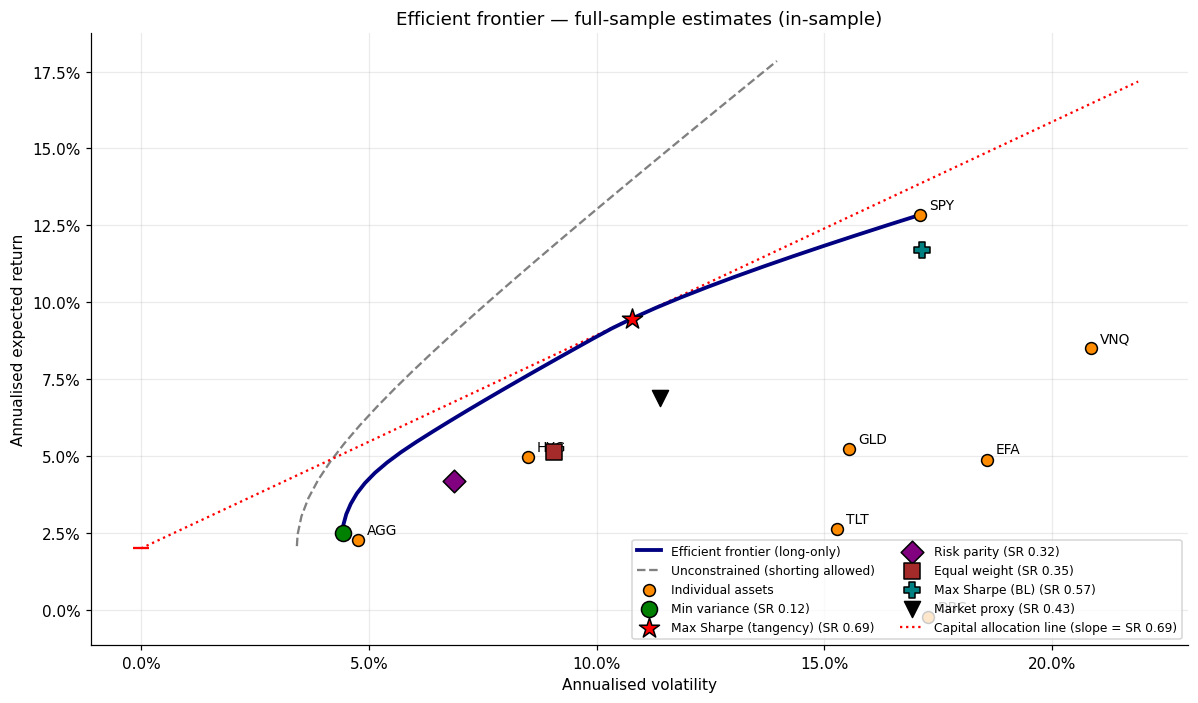

Note how far the unconstrained frontier sits above the long-only one. That gap is not free money — it is the optimizer taking large offsetting positions in near-collinear assets (SPY/EFA, AGG/TLT) on the strength of tiny estimated return differences that are well inside their confidence intervals.


In [18]:
# ============================================================================
# Efficient frontier
# ============================================================================
fig, ax = plt.subplots(figsize=(11, 6.5))

# Long-only frontier
ax.plot(frontier["vol"], frontier["ret"], "-", color="navy", lw=2.5,
        label="Efficient frontier (long-only)", zorder=3)
if len(frontier_ls):
    ax.plot(frontier_ls["vol"], frontier_ls["ret"], "--", color="grey", lw=1.5,
            label="Unconstrained (shorting allowed)", zorder=2)

# Individual assets
asset_vol = np.sqrt(np.diag(SIGMA))
ax.scatter(asset_vol, MU, s=60, c="darkorange", edgecolor="k", zorder=5, label="Individual assets")
for i, t in enumerate(TICKERS):
    ax.annotate(t, (asset_vol[i], MU[i]), textcoords="offset points",
                xytext=(6, 4), fontsize=9)

# Named portfolios
marks = [("Min variance", w_minvar, "o", "green"),
         ("Max Sharpe (tangency)", w_maxsharpe, "*", "red"),
         ("Risk parity", w_rp, "D", "purple"),
         ("Equal weight", w_eq, "s", "brown"),
         ("Max Sharpe (BL)", w_mvo_bl, "P", "teal"),
         ("Market proxy", W_MARKET, "v", "black")]
for name, w, marker, color in marks:
    r, v, s = portfolio_stats(w, MU, SIGMA)
    ax.scatter(v, r, marker=marker, s=190 if marker == "*" else 110,
               c=color, edgecolor="k", zorder=6, label=f"{name} (SR {s:.2f})")

# Capital allocation line through the tangency portfolio
r_t, v_t, s_t = portfolio_stats(w_maxsharpe, MU, SIGMA)
x_cal = np.linspace(0, max(asset_vol) * 1.05, 50)
ax.plot(x_cal, RF_ANNUAL + s_t * x_cal, ":", color="red", lw=1.5,
        label=f"Capital allocation line (slope = SR {s_t:.2f})")
ax.scatter([0], [RF_ANNUAL], marker="_", s=100, c="red")

ax.set_xlabel("Annualised volatility"); ax.set_ylabel("Annualised expected return")
ax.set_title("Efficient frontier — full-sample estimates (in-sample)")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend(fontsize=8, loc="lower right", ncol=2)
plt.tight_layout(); plt.show()

print("Note how far the unconstrained frontier sits above the long-only one. That gap is not free "
      "money — it is the optimizer taking large offsetting positions in near-collinear assets "
      "(SPY/EFA, AGG/TLT) on the strength of tiny estimated return differences that are well "
      "inside their confidence intervals.")

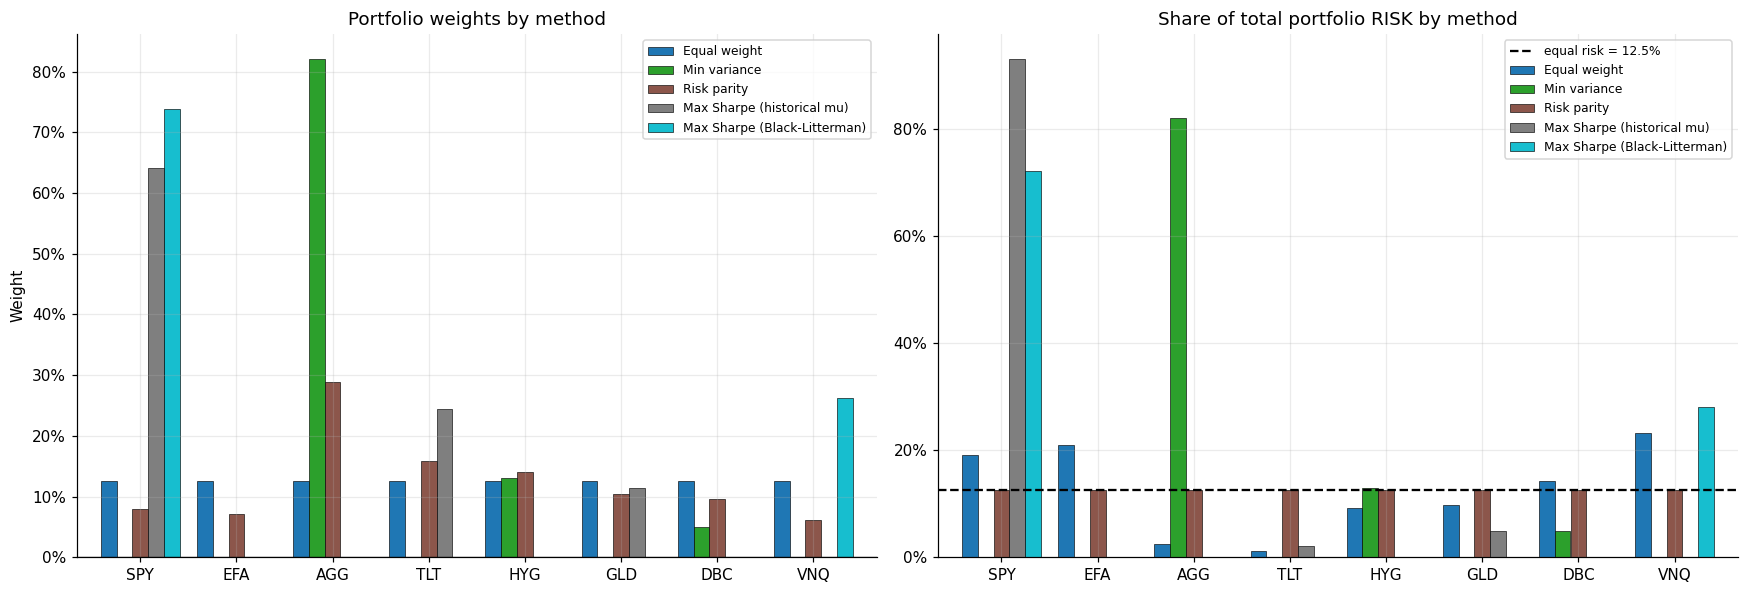

Under equal WEIGHTING, the largest single risk contributor is VNQ at 23.2% of total portfolio risk — versus a 12.5% weight. Equal weight is not equal risk; the volatile assets dominate.


In [19]:
# ============================================================================
# Weight allocation comparison
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

plot_cols = ["Equal weight", "Min variance", "Risk parity",
             "Max Sharpe (historical mu)", "Max Sharpe (Black-Litterman)"]
weights_all[plot_cols].plot(kind="bar", ax=axes[0], width=0.82,
                            colormap="tab10", edgecolor="k", lw=0.4)
axes[0].set_title("Portfolio weights by method")
axes[0].set_ylabel("Weight"); axes[0].axhline(0, color="k", lw=0.8)
axes[0].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[0].legend(fontsize=8); axes[0].tick_params(axis="x", rotation=0)

# Risk contributions, which is the more revealing view
rc_frame = pd.DataFrame(
    {name: risk_contributions(weights_all[name].to_numpy(), SIGMA) /
           risk_contributions(weights_all[name].to_numpy(), SIGMA).sum()
     for name in plot_cols}, index=TICKERS)
rc_frame.plot(kind="bar", ax=axes[1], width=0.82, colormap="tab10",
              edgecolor="k", lw=0.4)
axes[1].axhline(1 / N, color="k", ls="--", lw=1.5, label=f"equal risk = {1/N:.1%}")
axes[1].set_title("Share of total portfolio RISK by method")
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].legend(fontsize=8); axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout(); plt.show()

ew_rc = rc_frame["Equal weight"]
print(f"Under equal WEIGHTING, the largest single risk contributor is "
      f"{ew_rc.idxmax()} at {ew_rc.max():.1%} of total portfolio risk — versus a "
      f"{1/N:.1%} weight. Equal weight is not equal risk; the volatile assets dominate.")

## 6. Out-of-sample backtest

### 6.1 Design decisions and why each one matters

**Rolling 252-day estimation window.** One year of daily data. Short enough to adapt to changing
volatility regimes, long enough that $\Sigma$ (36 free parameters for 8 assets) is estimable —
252 observations for 36 parameters is a ratio of 7:1, which is thin but workable. This is why the
universe is 8 assets and not 50: at $N = 50$ you need 1,275 covariance parameters and a 252-day
window is rank-deficient, at which point $\Sigma^{-1}$ does not exist and every conclusion here
changes.

**Monthly rebalancing.** Daily rebalancing would multiply transaction costs and mostly trade
against estimation noise. Monthly is the standard institutional cadence.

**Weights drift between rebalances.** Between rebalance dates the portfolio is held, so weights
move with relative performance. Re-imposing target weights daily would be a different (and
costlier) strategy, and would quietly add a rebalancing-premium return that the strategy did not
actually earn.

**Transaction costs of 10bps on turnover.** Small, but not zero — and it is the mechanism by which
mean-variance's instability shows up as a real cost rather than just an aesthetic complaint.
Turnover is reported alongside returns for exactly this reason.

**No look-ahead.** Weights for month $t+1$ use data only through the last trading day of month $t$.
This is the single most common bug in backtests: estimating $\Sigma$ on the full sample and then
"backtesting" on it produces beautiful, meaningless results.

In [20]:
# ============================================================================
# Backtest engine
# ============================================================================

def run_backtest(strategies, returns_simple, returns_log, start_date,
                 lookback=LOOKBACK_DAYS, tc_bps=TC_BPS, rebalance=REBALANCE):
    """Walk-forward backtest with weight drift and turnover costs.

    strategies: dict of name -> f(mu, Sigma) -> weight vector
    Returns (daily net returns DataFrame, weights history dict, turnover Series).

    Ordering within each day matters and is easy to get wrong: the portfolio
    earns today's return on the weights it was ALREADY holding, and only then
    rebalances at today's close using information through today. Rebalancing
    first and then applying the same day's return would earn a day of
    performance on weights chosen with knowledge of that day -- a one-day
    look-ahead that quietly flatters every signal-driven strategy.
    """
    dates = returns_simple.loc[start_date:].index
    # Last actual TRADING day of each month, not the calendar month end.
    rebal_set = set(pd.Series(dates, index=dates).resample(rebalance).last().dropna())

    n_assets = returns_simple.shape[1]
    out_rets = {k: [] for k in strategies}
    out_wts = {k: {} for k in strategies}
    out_turnover = {k: [] for k in strategies}
    current_w = {k: np.repeat(1 / n_assets, n_assets) for k in strategies}
    funded = {k: False for k in strategies}

    for date in dates:
        r_today = returns_simple.loc[date].to_numpy()

        # ---- 1. earn today's return on the weights already held ------------
        for name in strategies:
            w = current_w[name]
            out_wts[name][date] = w.copy()
            out_rets[name].append((date, float(w @ r_today)))
            grown = w * (1 + r_today)          # weights drift with performance
            current_w[name] = grown / grown.sum()

        # ---- 2. rebalance at today's close, using data through today -------
        if date in rebal_set:
            window = returns_log.loc[:date].iloc[-lookback:]
            if len(window) >= lookback // 2:
                mu_w, sigma_w = annualised_moments(window)
                for name, fn in strategies.items():
                    try:
                        w_new = np.asarray(fn(mu_w, sigma_w), dtype=float).ravel()
                        if not np.all(np.isfinite(w_new)) or abs(w_new.sum()) < 1e-8:
                            raise ValueError("degenerate solution")
                        w_new = w_new / w_new.sum()
                    except Exception:
                        w_new = current_w[name]          # keep last good weights
                    turn = np.abs(w_new - current_w[name]).sum()
                    current_w[name] = w_new
                    # The first trade is the initial funding of the portfolio,
                    # not a rebalance -- charging it would penalise whichever
                    # strategy happens to start furthest from equal weight.
                    if funded[name]:
                        out_turnover[name].append((date, turn))
                        out_rets[name].append((date, -turn * tc_bps / 1e4))
                    funded[name] = True

    # collapse (date, value) pairs, summing cost and return on rebalance days
    net = {}
    for name, recs in out_rets.items():
        s = pd.Series(0.0, index=dates)
        for d, v in recs:
            s.loc[d] += v
        net[name] = s
    net = pd.DataFrame(net)
    wts = {k: pd.DataFrame(v).T for k, v in out_wts.items()}
    turn = {k: pd.Series(dict(v)) for k, v in out_turnover.items()}
    return net, wts, turn


# ---- strategy definitions: each is a pure function of (mu, Sigma) ----------
STRATEGIES = {
    "Equal weight":   lambda mu, S: np.repeat(1 / len(mu), len(mu)),
    "60/40":          lambda mu, S: np.array([0.6 if t == "SPY" else 0.4 if t == "AGG" else 0.0
                                              for t in TICKERS]),
    "Min variance":   lambda mu, S: min_variance_weights(S),
    "Risk parity":    lambda mu, S: risk_parity_weights(S)[0],
    "Max Sharpe (hist mu)": lambda mu, S: max_sharpe_weights(mu, S),
    "Max Sharpe (BL)": lambda mu, S: max_sharpe_weights(
        black_litterman(S, W_MARKET, P, Q, tau=0.05,
                        mkt_excess=float(mu @ W_MARKET) - RF_ANNUAL)[0], S),
}

TANGENCY_UNDEFINED["count"] = TANGENCY_UNDEFINED["total"] = 0   # reset the counter
bt_rets, bt_wts, bt_turn = run_backtest(STRATEGIES, simple_ret, log_ret, BACKTEST_START)
print(f"Backtest: {bt_rets.index[0]:%Y-%m-%d} to {bt_rets.index[-1]:%Y-%m-%d} "
      f"({len(bt_rets):,} days, {len(bt_turn['Risk parity']):,} rebalances)")
print(f"Strategies: {', '.join(bt_rets.columns)}")

und, tot = TANGENCY_UNDEFINED["count"], TANGENCY_UNDEFINED["total"]
print(f"\nTangency portfolio undefined in {und}/{tot} calls ({und / max(tot, 1):.0%}) — those "
      f"windows had no asset with a positive estimated excess return over {RF_ANNUAL:.0%}, so the "
      f"max-Sharpe strategies held the minimum-variance portfolio instead.")
if und / max(tot, 1) > 0.15:
    print("That fraction is high enough that the 'max Sharpe' lines below are part min-variance. "
          "It is itself evidence for the thesis: a 252-day estimate of mu is so noisy that it is "
          "frequently negative across every asset simultaneously.")

Backtest: 2015-01-02 to 2024-12-30 (2,515 days, 119 rebalances)
Strategies: Equal weight, 60/40, Min variance, Risk parity, Max Sharpe (hist mu), Max Sharpe (BL)

Tangency portfolio undefined in 40/240 calls (17%) — those windows had no asset with a positive estimated excess return over 2%, so the max-Sharpe strategies held the minimum-variance portfolio instead.
That fraction is high enough that the 'max Sharpe' lines below are part min-variance. It is itself evidence for the thesis: a 252-day estimate of mu is so noisy that it is frequently negative across every asset simultaneously.


In [21]:
# ============================================================================
# Performance metrics
# ============================================================================

def performance_summary(returns, rf=RF_ANNUAL, turnover=None):
    """Annualised return/vol/Sharpe/drawdown, plus a Sharpe standard error.

    The SE matters: with ~10 years of data, Sharpe ratios are estimated far less
    precisely than people assume, and most head-to-head differences in this table
    are not statistically distinguishable from zero.
    """
    rows = []
    n_years = len(returns) / TRADING_DAYS
    for name in returns.columns:
        r = returns[name]
        wealth = (1 + r).cumprod()
        ann_r = wealth.iloc[-1] ** (1 / n_years) - 1
        ann_v = r.std() * np.sqrt(TRADING_DAYS)
        sharpe = (ann_r - rf) / ann_v
        dd = wealth / wealth.cummax() - 1
        # Lo (2002) asymptotic SE for an iid Sharpe estimate
        se_sharpe = np.sqrt((1 + 0.5 * sharpe ** 2) / n_years)
        rows.append({
            "strategy": name,
            "ann. return": ann_r,
            "ann. vol": ann_v,
            "Sharpe": sharpe,
            "Sharpe SE": se_sharpe,
            "max drawdown": dd.min(),
            "Calmar": ann_r / abs(dd.min()) if dd.min() < 0 else np.nan,
            "worst month": r.resample("ME").apply(lambda x: (1 + x).prod() - 1).min(),
            "skew": r.skew(),
            "ann. turnover": (turnover[name].sum() / n_years) if turnover else np.nan,
        })
    return pd.DataFrame(rows).set_index("strategy")


perf = performance_summary(bt_rets, turnover=bt_turn)
display(perf.style.format({
    "ann. return": "{:.2%}", "ann. vol": "{:.2%}", "Sharpe": "{:.2f}",
    "Sharpe SE": "±{:.2f}", "max drawdown": "{:.1%}", "Calmar": "{:.2f}",
    "worst month": "{:.1%}", "skew": "{:.2f}", "ann. turnover": "{:.1f}x",
}).background_gradient(cmap="RdYlGn", subset=["Sharpe"]))

best, worst = perf["Sharpe"].idxmax(), perf["Sharpe"].idxmin()
gap = perf.loc[best, "Sharpe"] - perf.loc[worst, "Sharpe"]
pooled_se = np.sqrt(perf.loc[best, "Sharpe SE"] ** 2 + perf.loc[worst, "Sharpe SE"] ** 2)
print(f"Best Sharpe: {best} ({perf.loc[best, 'Sharpe']:.2f}) | "
      f"Worst: {worst} ({perf.loc[worst, 'Sharpe']:.2f})")
print(f"Gap {gap:.2f} against a pooled SE of roughly ±{pooled_se:.2f} "
      f"(t ≈ {gap / pooled_se:.2f}, and the strategies are highly correlated so this "
      f"overstates the true SE of the difference).")
print("\nThe honest reading: over a single 10-year path, these strategies are not cleanly "
      "separable on Sharpe alone. Ranking them by whoever won this sample is exactly the "
      "overfitting the notebook is arguing against. Turnover and drawdown are estimated far "
      "more precisely than Sharpe and deserve more weight in the decision.")

,ann. return,ann. vol,Sharpe,Sharpe SE,max drawdown,Calmar,worst month,skew,ann. turnover
strategy,,,,,,,,,
Equal weight,5.27%,9.04%,0.36,±0.33,-20.2%,0.26,-8.5%,-0.94,0.3x
60/40,8.85%,10.85%,0.63,±0.35,-21.6%,0.41,-7.7%,-0.73,0.2x
Min variance,1.78%,5.02%,-0.04,±0.32,-17.0%,0.10,-4.6%,-1.34,0.8x
Risk parity,3.81%,7.17%,0.25,±0.32,-18.5%,0.21,-6.2%,-0.87,0.5x
Max Sharpe (hist mu),3.07%,12.58%,0.08,±0.32,-30.9%,0.10,-9.0%,-0.85,6.4x
Max Sharpe (BL),4.88%,13.68%,0.21,±0.32,-33.9%,0.14,-14.0%,-1.46,4.6x


Best Sharpe: 60/40 (0.63) | Worst: Min variance (-0.04)
Gap 0.67 against a pooled SE of roughly ±0.47 (t ≈ 1.44, and the strategies are highly correlated so this overstates the true SE of the difference).

The honest reading: over a single 10-year path, these strategies are not cleanly separable on Sharpe alone. Ranking them by whoever won this sample is exactly the overfitting the notebook is arguing against. Turnover and drawdown are estimated far more precisely than Sharpe and deserve more weight in the decision.


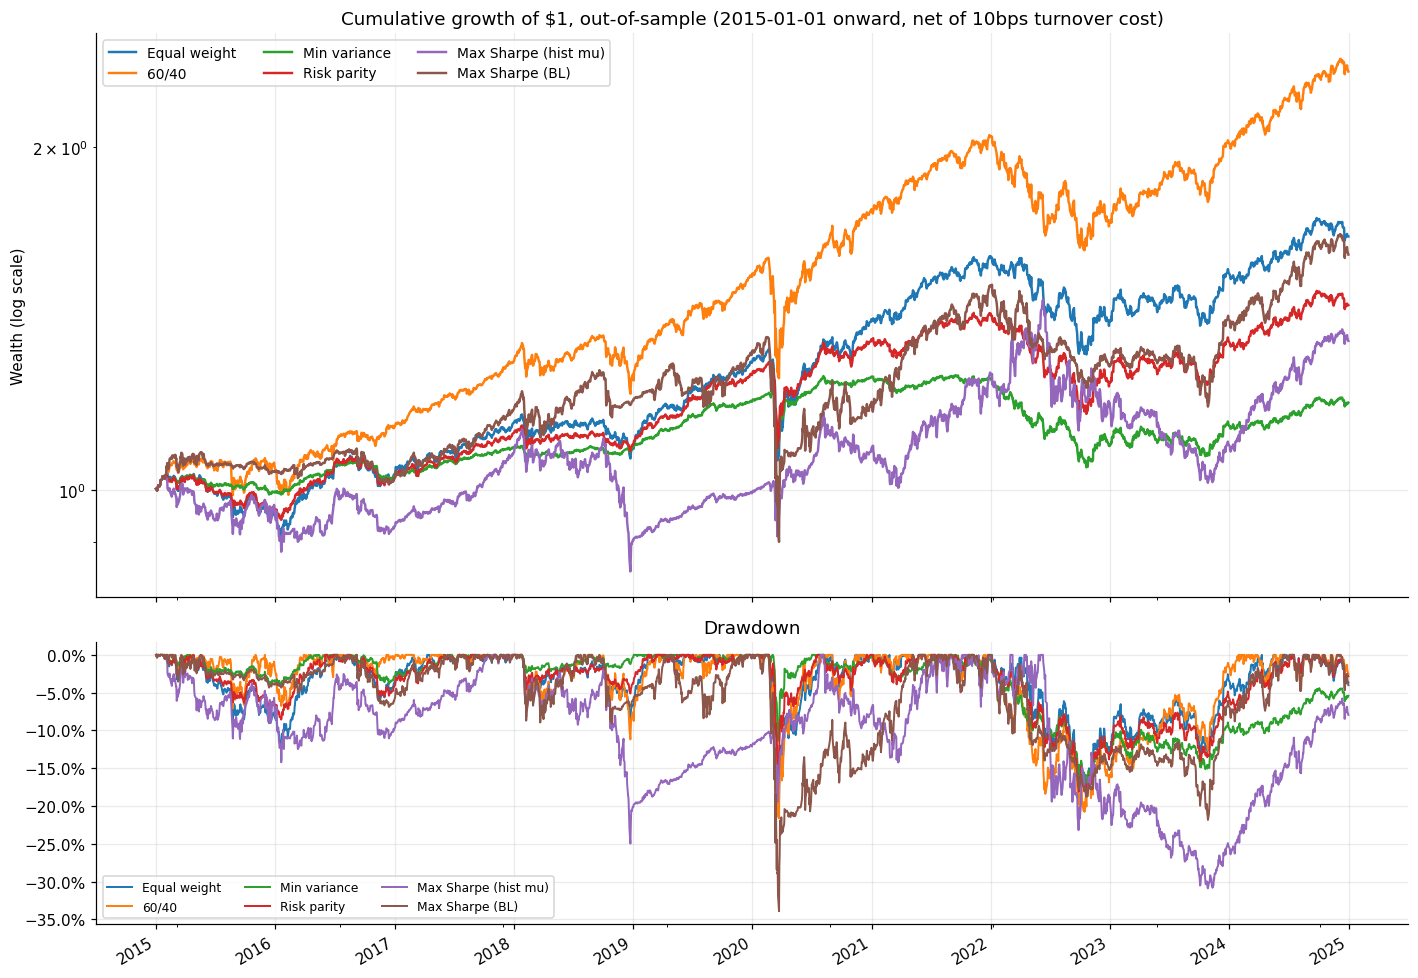

,Equal weight,60/40,Min variance,Risk parity,Max Sharpe (hist mu),Max Sharpe (BL)
Date,,,,,,
2015,-5.1%,4.7%,-0.3%,-3.8%,-4.8%,3.9%
2016,8.6%,8.2%,3.3%,6.4%,-2.6%,-1.8%
2017,10.9%,14.1%,5.9%,9.5%,16.0%,15.0%
2018,-4.8%,-2.4%,-0.0%,-2.2%,-16.0%,2.0%
2019,18.8%,21.9%,9.7%,15.0%,10.0%,10.1%
2020,9.2%,14.6%,5.2%,7.6%,9.5%,-9.4%
2021,13.6%,15.7%,-0.4%,5.3%,16.3%,26.4%
2022,-12.4%,-15.9%,-12.8%,-13.1%,-5.7%,-15.0%
2023,10.5%,17.6%,4.4%,8.9%,-8.0%,10.0%


Look at 2022 specifically. It is the year equities and duration fell together, which removes the diversification that risk parity and 60/40 both depend on. A strategy evaluated only on 2010-2021 would look far more robust than it is.


In [22]:
# ============================================================================
# Cumulative performance and drawdowns
# ============================================================================
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})

wealth = (1 + bt_rets).cumprod()
wealth.plot(ax=axes[0], lw=1.6)
axes[0].set_yscale("log")
axes[0].set_title(f"Cumulative growth of $1, out-of-sample ({BACKTEST_START} onward, "
                  f"net of {TC_BPS}bps turnover cost)")
axes[0].legend(fontsize=9, ncol=3); axes[0].set_ylabel("Wealth (log scale)")

dd = wealth / wealth.cummax() - 1
dd.plot(ax=axes[1], lw=1.3)
axes[1].set_title("Drawdown")
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].legend(fontsize=8, ncol=3); axes[1].set_xlabel("")

plt.tight_layout(); plt.show()

# Calendar-year returns: where the strategies actually diverge
annual = bt_rets.resample("YE").apply(lambda x: (1 + x).prod() - 1)
annual.index = annual.index.year
display(annual.style.format("{:.1%}").background_gradient(cmap="RdYlGn", axis=None))
print("Look at 2022 specifically. It is the year equities and duration fell together, which "
      "removes the diversification that risk parity and 60/40 both depend on. A strategy "
      "evaluated only on 2010-2021 would look far more robust than it is.")

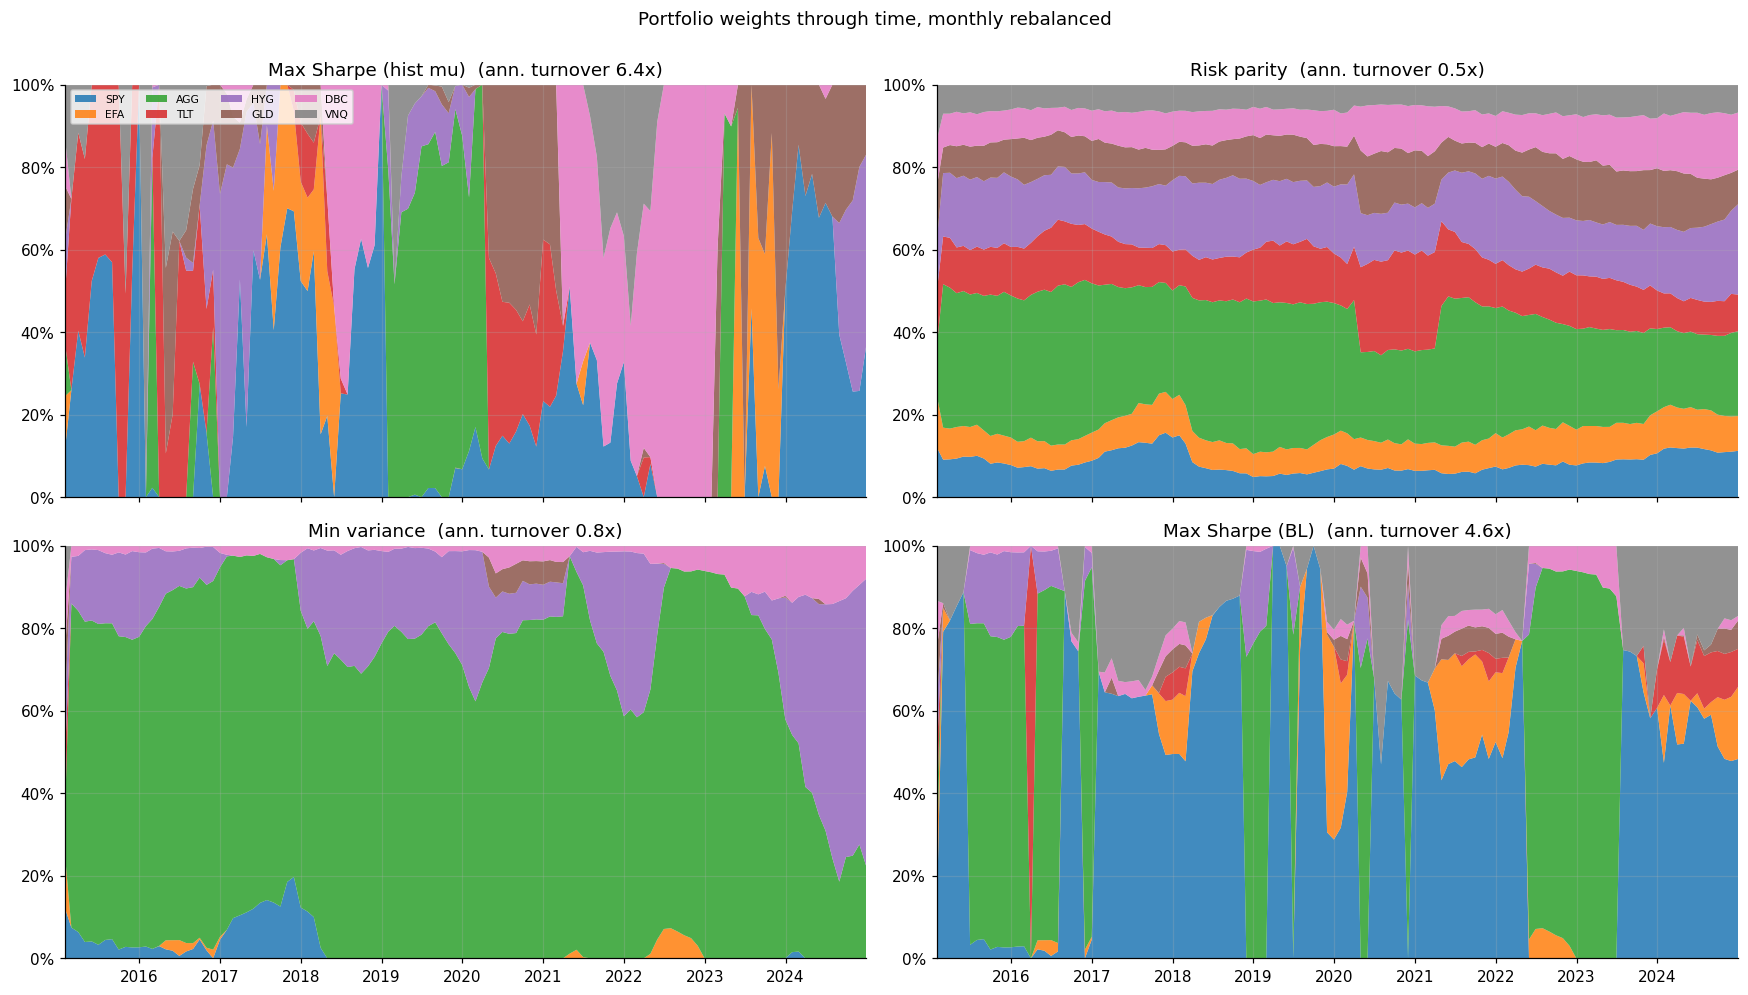

,ann. turnover,mean |Δw| per rebalance,max |Δw| in one rebalance
Max Sharpe (hist mu),6.365,0.534,2.000
Max Sharpe (BL),4.619,0.387,2.000
Min variance,0.832,0.070,0.297
Risk parity,0.475,0.040,0.361
Equal weight,0.270,0.023,0.085
60/40,0.183,0.015,0.062


Mean-variance rewrites the portfolio every month in response to a one-month change in the trailing estimate of mu. Risk parity's weights move slowly because volatility and correlation move slowly. This is the cost side of the stability argument, and it shows up as real money at any realistic transaction cost.


In [23]:
# ============================================================================
# Weight stability through time -- the instability made visible
# ============================================================================
show = ["Max Sharpe (hist mu)", "Risk parity", "Min variance", "Max Sharpe (BL)"]
fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex=True)

for ax, name in zip(axes.ravel(), show):
    w_hist = bt_wts[name].resample("ME").last()
    w_hist.columns = TICKERS
    ax.stackplot(w_hist.index, w_hist.T.to_numpy(), labels=TICKERS, alpha=0.85)
    ax.set_ylim(0, 1); ax.set_title(f"{name}  (ann. turnover {perf.loc[name, 'ann. turnover']:.1f}x)")
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.margins(x=0)
axes[0, 0].legend(fontsize=7, ncol=4, loc="upper left")

plt.suptitle("Portfolio weights through time, monthly rebalanced", y=1.00)
plt.tight_layout(); plt.show()

turn_tbl = pd.DataFrame({
    "ann. turnover": {k: v.sum() / (len(bt_rets) / TRADING_DAYS) for k, v in bt_turn.items()},
    "mean |Δw| per rebalance": {k: v.mean() for k, v in bt_turn.items()},
    "max |Δw| in one rebalance": {k: v.max() for k, v in bt_turn.items()},
}).sort_values("ann. turnover", ascending=False)
display(turn_tbl.round(3))
print("Mean-variance rewrites the portfolio every month in response to a one-month change in "
      "the trailing estimate of mu. Risk parity's weights move slowly because volatility and "
      "correlation move slowly. This is the cost side of the stability argument, and it shows "
      "up as real money at any realistic transaction cost.")

## 7. Sensitivity analysis

This is the core of the project, and it has to be done in two parts to be honest.

### 7.1 Part A: perturbing $\mu$ — and why this test is partly rigged

Scale each asset's expected return by a random factor in $[0.9, 1.1]$ — a $\pm 10\%$ perturbation,
far smaller than the estimation error quantified in section 2.1, where 95% confidence intervals on
$\mu$ spanned several hundred percent of the point estimate.

**Be upfront about what this shows.** Minimum-variance and risk parity do not take $\mu$ as an
input at all, so their sensitivity to it is *identically zero by construction*. That is a real
property and a real advantage — but demonstrating it is a tautology, not evidence. Any argument
that stops here is incomplete, and an interviewer will say so.

The genuine test is Part B.

In [24]:
# ============================================================================
# 7.1 Sensitivity to expected-return perturbations
# ============================================================================
N_DRAWS = 250
rng = np.random.default_rng(RANDOM_SEED)

pert_results = {"Max Sharpe (hist mu)": [], "Max Sharpe (BL)": [],
                "Min variance": [], "Risk parity": []}

for _ in range(N_DRAWS):
    shock = rng.uniform(0.9, 1.1, size=N)          # +/-10% on each expected return
    mu_pert = MU * shock

    pert_results["Max Sharpe (hist mu)"].append(max_sharpe_weights(mu_pert, SIGMA))
    mu_bl_p, _, _ = black_litterman(SIGMA, W_MARKET, P, Q, tau=0.05,
                                    mkt_excess=float(mu_pert @ W_MARKET) - RF_ANNUAL)
    pert_results["Max Sharpe (BL)"].append(max_sharpe_weights(mu_bl_p, SIGMA))
    pert_results["Min variance"].append(w_minvar)    # mu-free: unchanged by construction
    pert_results["Risk parity"].append(w_rp)         # mu-free: unchanged by construction

pert = {k: np.array(v) for k, v in pert_results.items()}

base_w = {"Max Sharpe (hist mu)": w_mvo_hist, "Max Sharpe (BL)": w_mvo_bl,
          "Min variance": w_minvar, "Risk parity": w_rp}

sens_mu = pd.DataFrame({
    "mean L1 distance from base": {k: np.abs(v - base_w[k]).sum(axis=1).mean()
                                   for k, v in pert.items()},
    "max L1 distance": {k: np.abs(v - base_w[k]).sum(axis=1).max() for k, v in pert.items()},
    "avg per-asset weight SD": {k: v.std(axis=0).mean() for k, v in pert.items()},
    "widest single-asset range": {k: (v.max(axis=0) - v.min(axis=0)).max()
                                  for k, v in pert.items()},
}).sort_values("mean L1 distance from base", ascending=False)
display(sens_mu.style.format("{:.4f}"))

worst_asset = TICKERS[int((pert["Max Sharpe (hist mu)"].max(axis=0)
                           - pert["Max Sharpe (hist mu)"].min(axis=0)).argmax())]
rng_worst = (pert["Max Sharpe (hist mu)"].max(axis=0)
             - pert["Max Sharpe (hist mu)"].min(axis=0)).max()
print(f"A +/-10% wiggle in expected returns moves the max-Sharpe allocation to {worst_asset} "
      f"across a {rng_worst:.1%} range of the portfolio.")
print("Black-Litterman's perturbed weights move less than naive MVO's because the equilibrium "
      "prior anchors them — the views are shrunk toward pi rather than taken at face value.")

,mean L1 distance from base,max L1 distance,avg per-asset weight SD,widest single-asset range
Max Sharpe (hist mu),0.0408,0.0968,0.0061,0.0968
Max Sharpe (BL),0.0002,0.0005,0.0000,0.0004
Min variance,0.0000,0.0000,0.0000,0.0000
Risk parity,0.0000,0.0000,0.0000,0.0000


A +/-10% wiggle in expected returns moves the max-Sharpe allocation to GLD across a 9.7% range of the portfolio.
Black-Litterman's perturbed weights move less than naive MVO's because the equilibrium prior anchors them — the views are shrunk toward pi rather than taken at face value.


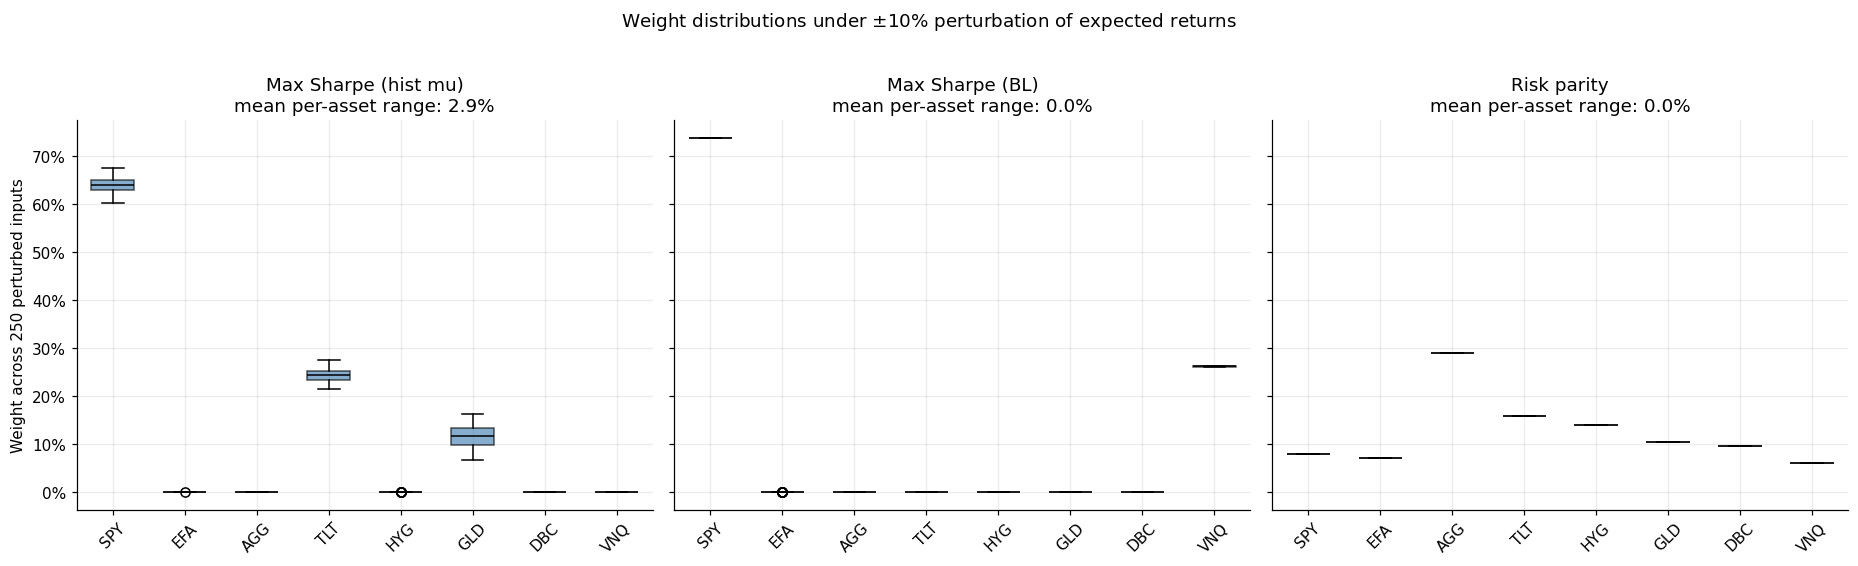

In [25]:
# ============================================================================
# Visualising the mu-sensitivity
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)

for ax, name in zip(axes, ["Max Sharpe (hist mu)", "Max Sharpe (BL)", "Risk parity"]):
    data = [pert[name][:, i] for i in range(N)]
    bp = ax.boxplot(data, tick_labels=TICKERS, patch_artist=True, widths=0.6,
                    medianprops=dict(color="black"))
    for patch in bp["boxes"]:
        patch.set_facecolor("steelblue"); patch.set_alpha(0.65)
    spread = np.mean([d.max() - d.min() for d in data])
    ax.set_title(f"{name}\nmean per-asset range: {spread:.1%}")
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.tick_params(axis="x", rotation=45)

axes[0].set_ylabel("Weight across 250 perturbed inputs")
plt.suptitle(r"Weight distributions under $\pm$10% perturbation of expected returns", y=1.02)
plt.tight_layout(); plt.show()

### 7.2 Part B: perturbing the data itself

Now the fair test. Rather than shocking $\mu$ directly, **resample the return history** and
re-estimate *everything* from the resampled data — $\mu$ and $\Sigma$ both. Every method now faces
genuine estimation error in the input it actually uses, so nothing is unchanged by construction.

The resampling is a **block bootstrap** with 21-day blocks rather than an i.i.d. bootstrap. Drawing
individual days independently would destroy volatility clustering and the serial structure that
makes the crisis periods look like crises, and would understate how much a realistic alternative
sample path can differ. Blocks preserve within-month dynamics while randomising which months
appear.

Each bootstrap sample is a plausible alternative history of the same length. The spread of weights
across those histories is the estimation risk baked into each method.

In [26]:
# ============================================================================
# 7.2 Block-bootstrap sensitivity: BOTH mu and Sigma are re-estimated
# ============================================================================
N_BOOT = 200
BLOCK = 21                                  # ~1 month blocks

ret_arr = log_ret.to_numpy()
T = len(ret_arr)
n_blocks = int(np.ceil(T / BLOCK))
rng = np.random.default_rng(RANDOM_SEED + 1)

boot = {k: [] for k in ["Max Sharpe (hist mu)", "Max Sharpe (BL)",
                        "Min variance", "Risk parity", "Equal weight"]}

for _ in range(N_BOOT):
    starts = rng.integers(0, T - BLOCK, size=n_blocks)
    idx = np.concatenate([np.arange(s, s + BLOCK) for s in starts])[:T]
    sample = pd.DataFrame(ret_arr[idx], columns=TICKERS)

    mu_b, sigma_b = annualised_moments(sample)

    boot["Max Sharpe (hist mu)"].append(max_sharpe_weights(mu_b, sigma_b))
    mu_bl_b, _, _ = black_litterman(sigma_b, W_MARKET, P, Q, tau=0.05,
                                    mkt_excess=float(mu_b @ W_MARKET) - RF_ANNUAL)
    boot["Max Sharpe (BL)"].append(max_sharpe_weights(mu_bl_b, sigma_b))
    boot["Min variance"].append(min_variance_weights(sigma_b))
    boot["Risk parity"].append(risk_parity_weights(sigma_b)[0])
    boot["Equal weight"].append(w_eq)

boot = {k: np.array(v) for k, v in boot.items()}

sens_boot = pd.DataFrame({
    "mean L1 distance from base": {k: np.abs(v - v.mean(axis=0)).sum(axis=1).mean()
                                   for k, v in boot.items()},
    "avg per-asset weight SD": {k: v.std(axis=0).mean() for k, v in boot.items()},
    "widest single-asset range": {k: (v.max(axis=0) - v.min(axis=0)).max()
                                  for k, v in boot.items()},
    "avg effective N": {k: np.mean(1 / np.sum(v ** 2, axis=1)) for k, v in boot.items()},
}).sort_values("mean L1 distance from base", ascending=False)
display(sens_boot.style.format({
    "mean L1 distance from base": "{:.4f}", "avg per-asset weight SD": "{:.4f}",
    "widest single-asset range": "{:.1%}", "avg effective N": "{:.2f}"}))

ratio = (sens_boot.loc["Max Sharpe (hist mu)", "avg per-asset weight SD"] /
         sens_boot.loc["Risk parity", "avg per-asset weight SD"])
print(f"Under identical estimation error in the underlying data, max-Sharpe weights are "
      f"{ratio:.1f}x more dispersed than risk-parity weights.")
print("This is the result that actually supports the risk-parity case: not that it ignores mu, "
      "but that the quantity it does depend on (Sigma) is estimated far more precisely than the "
      "quantity mean-variance depends on.")

,mean L1 distance from base,avg per-asset weight SD,widest single-asset range,avg effective N
Max Sharpe (hist mu),0.5234,0.1006,100.0%,2.03
Max Sharpe (BL),0.2903,0.0706,100.0%,1.62
Min variance,0.0515,0.0084,19.4%,1.43
Risk parity,0.0383,0.0059,7.6%,6.09
Equal weight,0.0000,0.0000,0.0%,8.00


Under identical estimation error in the underlying data, max-Sharpe weights are 17.0x more dispersed than risk-parity weights.
This is the result that actually supports the risk-parity case: not that it ignores mu, but that the quantity it does depend on (Sigma) is estimated far more precisely than the quantity mean-variance depends on.


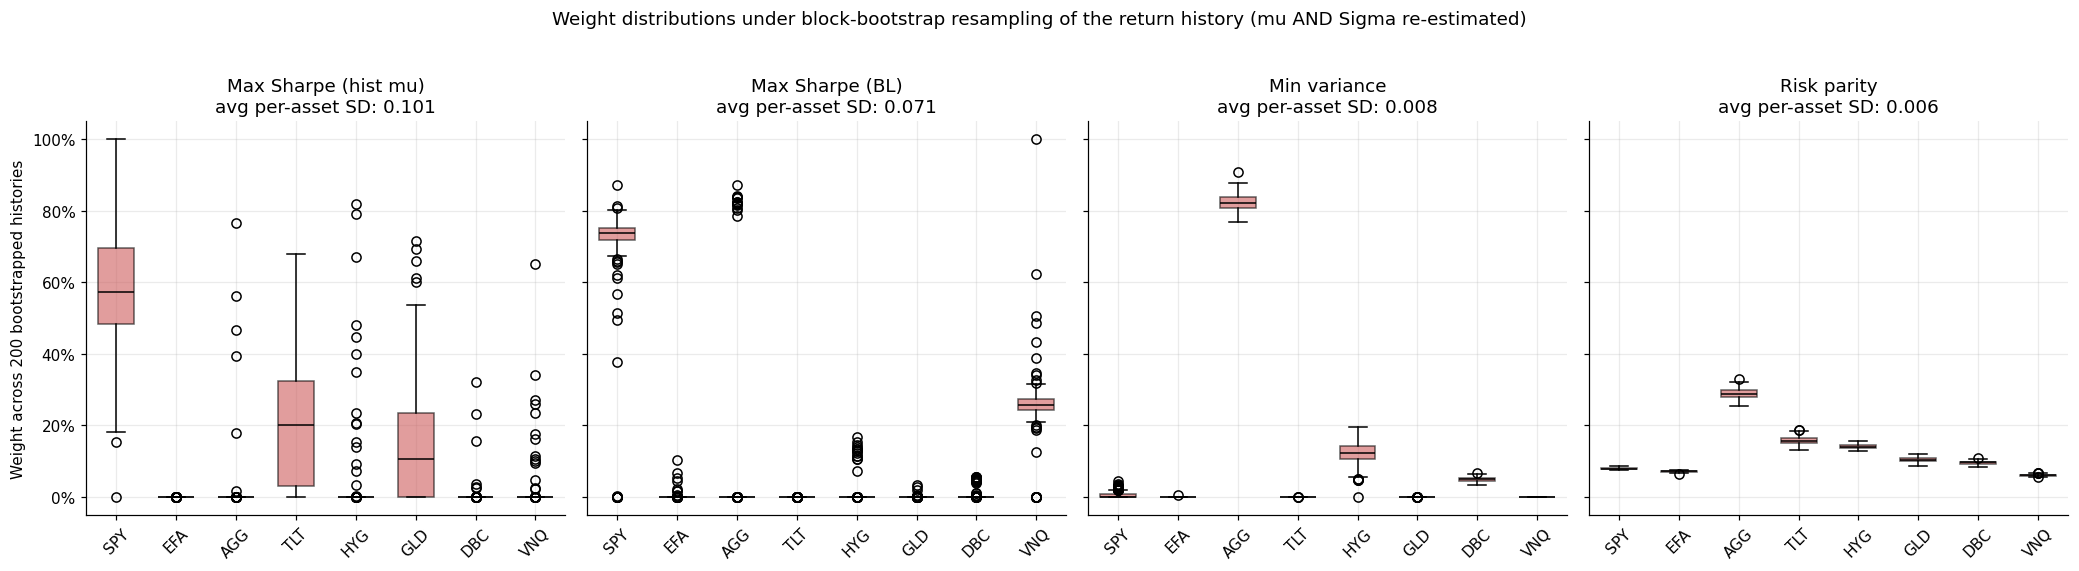

Fraction of bootstrap samples in which each asset is effectively excluded (<0.5%):


,Max Sharpe (hist mu),Max Sharpe (BL),Min variance,Risk parity
SPY,0%,8%,70%,0%
EFA,100%,96%,100%,0%
AGG,97%,93%,0%,0%
TLT,22%,100%,100%,0%
HYG,92%,93%,0%,0%
GLD,35%,98%,100%,0%
DBC,97%,92%,0%,0%
VNQ,93%,7%,100%,0%


Corner solutions are the signature of an error-maximizing optimizer: whole asset classes appear and vanish depending on which alternative history you happen to draw.


In [27]:
# ============================================================================
# Bootstrap weight distributions
# ============================================================================
fig, axes = plt.subplots(1, 4, figsize=(19, 5), sharey=True)

for ax, name in zip(axes, ["Max Sharpe (hist mu)", "Max Sharpe (BL)",
                           "Min variance", "Risk parity"]):
    data = [boot[name][:, i] for i in range(N)]
    bp = ax.boxplot(data, tick_labels=TICKERS, patch_artist=True, widths=0.6,
                    medianprops=dict(color="black"))
    for patch in bp["boxes"]:
        patch.set_facecolor("indianred"); patch.set_alpha(0.6)
    ax.set_title(f"{name}\navg per-asset SD: "
                 f"{sens_boot.loc[name, 'avg per-asset weight SD']:.3f}")
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.tick_params(axis="x", rotation=45)

axes[0].set_ylabel(f"Weight across {N_BOOT} bootstrapped histories")
plt.suptitle("Weight distributions under block-bootstrap resampling of the return history "
             "(mu AND Sigma re-estimated)", y=1.03)
plt.tight_layout(); plt.show()

# How often does max-Sharpe drop an asset entirely?
zero_freq = pd.DataFrame({
    name: (boot[name] < 0.005).mean(axis=0)
    for name in ["Max Sharpe (hist mu)", "Max Sharpe (BL)", "Min variance", "Risk parity"]
}, index=TICKERS)
print("Fraction of bootstrap samples in which each asset is effectively excluded (<0.5%):")
display(zero_freq.style.format("{:.0%}").background_gradient(cmap="Reds", axis=None))
print("Corner solutions are the signature of an error-maximizing optimizer: whole asset classes "
      "appear and vanish depending on which alternative history you happen to draw.")

## 8. Conclusion

In [28]:
# ============================================================================
# Auto-generated summary -- every figure is pulled from the objects above
# ============================================================================
rp_sharpe = perf.loc["Risk parity", "Sharpe"]
mv_sharpe = perf.loc["Max Sharpe (hist mu)", "Sharpe"]
ew_sharpe = perf.loc["Equal weight", "Sharpe"]

sd_mvo = sens_boot.loc["Max Sharpe (hist mu)", "avg per-asset weight SD"]
sd_rp = sens_boot.loc["Risk parity", "avg per-asset weight SD"]
turn_mvo = perf.loc["Max Sharpe (hist mu)", "ann. turnover"]
turn_rp = perf.loc["Risk parity", "ann. turnover"]

if rp_sharpe > mv_sharpe:
    oos_verdict = (f"Risk parity beat naive mean-variance out of sample "
                   f"({rp_sharpe:.2f} vs {mv_sharpe:.2f} Sharpe), despite mean-variance winning "
                   f"the in-sample comparison by construction.")
else:
    oos_verdict = (f"Mean-variance edged risk parity on realised Sharpe "
                   f"({mv_sharpe:.2f} vs {rp_sharpe:.2f}) over this particular path — a "
                   f"reminder that the stability argument is about the distribution of outcomes "
                   f"across possible histories, not a guarantee about any one of them.")

if ew_sharpe >= max(rp_sharpe, mv_sharpe) - 0.05:
    ew_note = (f"**Equal weight scored {ew_sharpe:.2f}, competitive with everything more "
               f"sophisticated.** This replicates DeMiguel, Garlappi and Uppal (2009), who found "
               f"1/N beat 14 optimization models out of sample on most datasets. Any optimizer "
               f"that cannot beat 1/N net of costs is not earning its complexity.")
else:
    ew_note = (f"Equal weight scored {ew_sharpe:.2f}, below the optimized portfolios here — but "
               f"it remains the benchmark worth beating, per DeMiguel, Garlappi and Uppal (2009).")

data_warning = ("\n> ⚠️ **Synthetic data** — the yfinance download was unavailable, so these "
                "figures come from the four-factor generator. Magnitudes are illustrative; the "
                "qualitative relationships (mean-variance instability, risk-parity stability, the "
                "2022 correlation breakdown) are built into the generating process and are "
                "therefore assumed rather than discovered. Re-run with live data before quoting "
                "any number.\n" if IS_SYNTHETIC else "")

# to_markdown needs the optional `tabulate` package; fall back to plain text.
_cols = ['ann. return', 'ann. vol', 'Sharpe', 'max drawdown', 'ann. turnover']
try:
    perf_table_md = perf[_cols].to_markdown(floatfmt='.3f')
except ImportError:
    perf_table_md = "```\n" + perf[_cols].round(3).to_string() + "\n```"

summary = f"""
# Summary

{data_warning}
**Data:** {DATA_SOURCE} · {len(TICKERS)} assets · {prices.index[0]:%Y-%m-%d} to {prices.index[-1]:%Y-%m-%d}
**Backtest:** {bt_rets.index[0]:%Y-%m-%d} onward · {LOOKBACK_DAYS}-day lookback · monthly rebalance · {TC_BPS}bps costs

## Out-of-sample results

{perf_table_md}

{oos_verdict}

Sharpe standard errors are roughly ±{perf['Sharpe SE'].mean():.2f} on a {len(bt_rets) / TRADING_DAYS:.0f}-year
sample, so most pairwise differences in that column are inside the noise. **Turnover and drawdown
are the columns estimated precisely enough to act on.**

{ew_note}

## The central finding

Under block-bootstrap resampling — where every method faces real estimation error in the inputs it
actually uses — mean-variance weights are **{sd_mvo / sd_rp:.1f}x more dispersed** than risk-parity
weights (average per-asset SD {sd_mvo:.3f} vs {sd_rp:.3f}). That instability is not cosmetic: it
shows up as {turn_mvo:.1f}x annual turnover versus {turn_rp:.1f}x for risk parity, which is a
direct, recurring cost.

The mechanism traces back to section 2.1. Expected returns have a standard error of
$\\sigma/\\sqrt{{\\text{{years}}}}$ that no amount of higher-frequency sampling reduces, while
volatility estimates improve with sampling frequency. Mean-variance depends on the quantity you
cannot estimate; risk parity depends only on the one you can.

## When each approach is preferable

**Mean-variance** is right when you have a genuine, defensible view on expected returns — a
signal with out-of-sample evidence behind it, not a sample mean. Its machinery is the correct way
to convert a return forecast into positions. Used with historical means as a stand-in for a
forecast, it is an expensive way to extrapolate whatever happened to work in the lookback window.

**Minimum variance** drops $\\mu$ but still inverts $\\Sigma$, so it inherits the conditioning
problem and concentrates in low-volatility assets — an implicit and quite large bet on the
low-volatility anomaly. It suits mandates written in terms of absolute risk.

**Risk parity** is the right default when you have no defensible return view and want a portfolio
that is diversified in *risk* rather than in dollars. Its weaknesses are real and specific: it is
structurally long duration, so it suffers when stocks and bonds sell off together (see the 2022
column above); at institutional scale it is typically levered to hit a volatility target, which
introduces funding and forced-deleveraging risk this unlevered version does not capture; and it
still assumes $\\Sigma$ is stable, which the rolling-correlation plot in section 1 shows it is not.

**Black-Litterman** is what to reach for when you *do* have views but want the optimizer to stay
sane. It shrinks views toward an equilibrium prior that is consistent with $\\Sigma$ by
construction, and it propagates a view on one asset through to correlated assets — the coupling
that naive mean-variance lacks. Its bootstrap dispersion sits between naive MVO and risk parity,
which is exactly the intended behaviour.

## What would strengthen this analysis

1. **Ledoit-Wolf shrinkage** on $\\Sigma$ — an obvious and cheap improvement, and the standard fix
   for the conditioning problem in section 1. Would likely narrow the mean-variance dispersion
   measurably.
2. **Robust/resampled optimization** — Michaud resampling, or a min-max formulation over an
   uncertainty set for $\\mu$, which addresses the error-maximizing property directly rather than
   by avoiding $\\mu$ altogether.
3. **Multiple sample paths.** Every number here rests on one realised history. Bootstrapping the
   *backtest* — not just the weights — would give a distribution of Sharpe outcomes and reveal how
   much of the ranking is luck.
4. **A volatility target with leverage** on the risk-parity sleeve, which is how it is actually
   run institutionally, and which would change the drawdown profile substantially.
5. **Turnover constraints or weight-change penalties** in the optimizer, which is the practical
   fix for mean-variance instability when you are committed to using it.
"""
display(Markdown(summary))


# Summary


**Data:** Yahoo Finance (live download) · 8 assets · 2010-01-04 to 2024-12-30
**Backtest:** 2015-01-02 onward · 252-day lookback · monthly rebalance · 10bps costs

## Out-of-sample results

| strategy             |   ann. return |   ann. vol |   Sharpe |   max drawdown |   ann. turnover |
|:---------------------|--------------:|-----------:|---------:|---------------:|----------------:|
| Equal weight         |         0.053 |      0.090 |    0.362 |         -0.202 |           0.270 |
| 60/40                |         0.088 |      0.109 |    0.631 |         -0.216 |           0.183 |
| Min variance         |         0.018 |      0.050 |   -0.043 |         -0.170 |           0.832 |
| Risk parity          |         0.038 |      0.072 |    0.253 |         -0.185 |           0.475 |
| Max Sharpe (hist mu) |         0.031 |      0.126 |    0.085 |         -0.309 |           6.365 |
| Max Sharpe (BL)      |         0.049 |      0.137 |    0.211 |         -0.339 |           4.619 |

Risk parity beat naive mean-variance out of sample (0.25 vs 0.08 Sharpe), despite mean-variance winning the in-sample comparison by construction.

Sharpe standard errors are roughly ±0.32 on a 10-year
sample, so most pairwise differences in that column are inside the noise. **Turnover and drawdown
are the columns estimated precisely enough to act on.**

**Equal weight scored 0.36, competitive with everything more sophisticated.** This replicates DeMiguel, Garlappi and Uppal (2009), who found 1/N beat 14 optimization models out of sample on most datasets. Any optimizer that cannot beat 1/N net of costs is not earning its complexity.

## The central finding

Under block-bootstrap resampling — where every method faces real estimation error in the inputs it
actually uses — mean-variance weights are **17.0x more dispersed** than risk-parity
weights (average per-asset SD 0.101 vs 0.006). That instability is not cosmetic: it
shows up as 6.4x annual turnover versus 0.5x for risk parity, which is a
direct, recurring cost.

The mechanism traces back to section 2.1. Expected returns have a standard error of
$\sigma/\sqrt{\text{years}}$ that no amount of higher-frequency sampling reduces, while
volatility estimates improve with sampling frequency. Mean-variance depends on the quantity you
cannot estimate; risk parity depends only on the one you can.

## When each approach is preferable

**Mean-variance** is right when you have a genuine, defensible view on expected returns — a
signal with out-of-sample evidence behind it, not a sample mean. Its machinery is the correct way
to convert a return forecast into positions. Used with historical means as a stand-in for a
forecast, it is an expensive way to extrapolate whatever happened to work in the lookback window.

**Minimum variance** drops $\mu$ but still inverts $\Sigma$, so it inherits the conditioning
problem and concentrates in low-volatility assets — an implicit and quite large bet on the
low-volatility anomaly. It suits mandates written in terms of absolute risk.

**Risk parity** is the right default when you have no defensible return view and want a portfolio
that is diversified in *risk* rather than in dollars. Its weaknesses are real and specific: it is
structurally long duration, so it suffers when stocks and bonds sell off together (see the 2022
column above); at institutional scale it is typically levered to hit a volatility target, which
introduces funding and forced-deleveraging risk this unlevered version does not capture; and it
still assumes $\Sigma$ is stable, which the rolling-correlation plot in section 1 shows it is not.

**Black-Litterman** is what to reach for when you *do* have views but want the optimizer to stay
sane. It shrinks views toward an equilibrium prior that is consistent with $\Sigma$ by
construction, and it propagates a view on one asset through to correlated assets — the coupling
that naive mean-variance lacks. Its bootstrap dispersion sits between naive MVO and risk parity,
which is exactly the intended behaviour.

## What would strengthen this analysis

1. **Ledoit-Wolf shrinkage** on $\Sigma$ — an obvious and cheap improvement, and the standard fix
   for the conditioning problem in section 1. Would likely narrow the mean-variance dispersion
   measurably.
2. **Robust/resampled optimization** — Michaud resampling, or a min-max formulation over an
   uncertainty set for $\mu$, which addresses the error-maximizing property directly rather than
   by avoiding $\mu$ altogether.
3. **Multiple sample paths.** Every number here rests on one realised history. Bootstrapping the
   *backtest* — not just the weights — would give a distribution of Sharpe outcomes and reveal how
   much of the ranking is luck.
4. **A volatility target with leverage** on the risk-parity sleeve, which is how it is actually
   run institutionally, and which would change the drawdown profile substantially.
5. **Turnover constraints or weight-change penalties** in the optimizer, which is the practical
   fix for mean-variance instability when you are committed to using it.
